# Packages & Utilities 

In [23]:
import os
import json
import pdb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")
import random

# Time series
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import TimeSeriesSplit

# LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import LSTM
from tensorflow.keras.optimizers import Adam
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler

# Jump Diffusion 
from sklearn.preprocessing import StandardScaler

# Process Track 
from tqdm import tqdm


# Utilities 
def get_online_quantile(scores, q_1, etas, alpha):
    """
    Computes the online quantile of a set of scores.
    :param scores: (np.array) The scores.
    :param q_1: (float) The quantile to compute.
    :param eta: (np.array) The sequence of learning rates.
    :return: (float) The sequence of online quantiles.
    """
    T = scores.shape[0]
    q = np.zeros(T)
    q[0] = q_1
    for t in range(T):
        err_t = (scores[t] > q[t]).astype(int)
        if t < T - 1:
            q[t + 1] = q[t] - etas[t] * (alpha - err_t)
    return q


def compute_coverage_metrics(Y, Yhat, alpha, epsilon, W, C):
    """
    Compute online quantiles, observed coverages

    Parameters:
        scores (numpy array): Array of scores for the main dataset.
        scores_val (numpy array): Array of scores for the validation dataset.
        alpha (float): 1 - alpha is the desired coverage level.
        epsilon (float): Decay parameter for eta in the decaying quantile.
        W (int): Window size for rolling coverage computation.
        C: Constant of etas decaying 

    Returns:
        dict: Dictionary containing all computed metrics.
    """
    scores = np.abs(Y - Yhat)
    T = len(scores)
    
    # Define learning rates
    etas_decaying = C * (np.array([1 / (t ** (1 / 2 + epsilon)) for t in range(1, T + 1)]))

    # Initialize first quantile value
    q_1 = scores[0]

    # Compute online quantiles
    q_decaying = get_online_quantile(scores, q_1, etas_decaying, alpha)

    # Compute observed coverage
    observed_coverages_decaying = (scores <= q_decaying).astype(int)

    # Compute long-run coverage
    LRC_decaying = np.cumsum(observed_coverages_decaying) / (np.arange(len(observed_coverages_decaying)) + 1)


    return {
        "T":T,
        "q_decaying": q_decaying,
        "observed_coverages_decaying": observed_coverages_decaying,
        "LRC_decaying": LRC_decaying,
    }

def plot_coverage_results(results, alpha, W):
    """
    Plots the quantile evolution, long-run coverage
    for a single dataset using results from compute_coverage_metrics.

    Parameters:
        results (dict): Dictionary output from compute_coverage_metrics.
        alpha (float): 1 - alpha is the desired coverage level.
        W (int): Window size for rolling coverage computation.

    Returns:
        None (Displays the plot).
    """

    T = results['T']

    sns.set_style("white")
    sns.set_palette("Set2")
    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["q_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    #plt.plot(range(T), results["q_star"] * np.ones_like(results["q_decaying"]), label=r'$q^*$')
    plt.ylabel(r'$q_t$')
    plt.xlabel(r'time $t$')
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.plot(range(T), results["LRC_decaying"], label=r'$\eta_t = \frac{1}{t^{1/2+\epsilon}}$')
    plt.axhline(y=1 - alpha, linestyle='dotted', color="k", linewidth=2, label=r'$1-\alpha$')
    plt.xlabel(r'time $t$')
    plt.ylabel("long-run coverage")
    plt.legend()
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()


def create_sequences(data, seq_length, train_ratio=0.8):
    data = np.array(data) 
    data_len = len(data)
    train_size = int(data_len * train_ratio)

    train_data = data[:train_size]
    test_data  = data[train_size:] 

    # Training sequences
    X_train, y_train = [], []
    for i in range(len(train_data) - seq_length):
        X_train.append(train_data[i:i+seq_length])
        y_train.append(train_data[i+seq_length])

    # Testing sequences
    X_test, y_test = [], []
    for i in range(len(test_data) - seq_length):
        X_test.append(test_data[i:i+seq_length])
        y_test.append(test_data[i+seq_length])

    # Reshape for LSTM [samples, timesteps, features]
    X_train = np.array(X_train).reshape(-1, seq_length, 1)
    y_train = np.array(y_train)
    X_test  = np.array(X_test).reshape(-1, seq_length, 1)
    y_test  = np.array(y_test)

    return X_train, X_test, y_train, y_test


# COMA 


def hedge(loss_matrix, eta):
    """
    Hedge algorithm.

    Parameters
    ----------
    loss_matrix : np.ndarray
        Shape (N, K), loss of K experts during N rounds.
    eta : float
        Learning rate parameter.

    Returns
    -------
    dict
        h : np.ndarray of shape (N,)
            Weighted average loss at each round.
        weights : np.ndarray of shape (N, K)
            Expert weights at each round.
    """
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)          # vector of length N
    weights = np.full((N, K), np.nan)  # N x K matrix
    w = np.full(K, 1.0 / K)         # start uniform weights

    for t in range(N):
        weights[t, :] = w
        w = w * np.exp(-eta * loss_matrix[t, :])  # exponential weighting
        w = w / np.sum(w)                         # normalize
        h[t] = np.sum(w * loss_matrix[t, :])      # weighted average loss

    return {"h": h, "weights": weights}


def counts_int(M, a, b, w):
    """
    Compute weighted fraction of intervals in M that cover the midpoint of [a,b].
    
    Parameters
    ----------
    M : np.ndarray
        Shape (n, 2), intervals with lower and upper bounds.
    a, b : float
        Interval boundaries.
    w : np.ndarray
        Weights for each interval (length n).
    
    Returns
    -------
    float
        Weighted mean (between 0 and 1).
    """
    mid = 0.5 * (a + b)
    inside = (M[:, 0] <= mid) & (mid <= M[:, 1]) 
    inside = inside.astype(float)                  
    num_int = np.average(inside, weights=w)
    return num_int


def mix(L, eta):
    """
    Python translation of R mix().
    """
    mn = np.min(L)

    if np.isinf(eta):
        w = (L == mn).astype(float)
        w /= w.sum()
    else:
        w = np.exp(-eta * (L - mn))

    s = np.sum(w)
    w = w / s
    M = mn - (1.0 / eta) * np.log(s / len(L)) if not np.isinf(eta) else mn

    return {"w": w, "M": M}

def adahedge(loss_matrix):
    N, K = loss_matrix.shape
    h = np.full(N, np.nan)
    L = np.zeros(K)
    etas = np.full(N, np.nan)
    weights = np.full((N, K), np.nan)
    Delta = 0.0

    for t in range(N):
        eta = np.log(K) / Delta if Delta > 0 else np.inf
        result = mix(L, eta=eta)
        w, Mprev = result["w"], result["M"]

        h[t] = np.dot(w, loss_matrix[t])
        weights[t] = w
        L = L + loss_matrix[t]

        result = mix(L, eta=eta)
        delta = max(0.0, h[t] - (result["M"] - Mprev))
        Delta += delta
        etas[t] = eta

    return {"h": h, "weights": weights, "eta": etas}



def majority_vote(M, w, rho):
    breaks = np.unique(M.flatten())
    breaks.sort()

    lower, upper = [], []

    if np.mean(np.isinf(M[:, 1])) > rho:
        return np.array([[-np.inf, np.inf]])

    i = 0
    while i < len(breaks) - 1:
        cond = counts_int(M, breaks[i], breaks[i+1], w) > rho
        if cond:
            lower.append(breaks[i])
            j = i
            while j < len(breaks) - 1 and cond:
                j += 1
                if j < len(breaks) - 1:   
                    cond = counts_int(M, breaks[j], breaks[j+1], w) > rho
                else:
                    cond = False
            upper.append(breaks[j])
            i = j
        i += 1

    if not lower:
        return np.nan
    else:
        return np.column_stack([lower, upper])


def covr_fun(ci, target):
    """
    Coverage function: check if target lies inside interval(s).
    
    ci: np.ndarray (L, 2) or (2,), interval(s)
    target: float, true value
    
    Returns: 1 if covered, 0 otherwise
    """
    if isinstance(ci, float) and np.isnan(ci):
        return 0

    ci = np.atleast_2d(ci)
    covr = 0
    for l, u in ci:
        covr += int((l <= target) and (target <= u))
    return covr

import numpy as np

def loss_fun(ci):
    """
    Compute the width of confidence interval(s).
    
    Parameters
    ----------
    ci : np.ndarray or list
         - shape (2,)   → single interval [low, high]
         - shape (L, 2) → multiple intervals
         - np.nan       → no interval
    
    Returns
    -------
    float
        total width (sum of all intervals' widths)
    """

    if ci is None or (isinstance(ci, float) and np.isnan(ci)):
        return 0.0
    ci = np.atleast_2d(ci)
    
    width = 0.0
    for l, u in ci:
        if np.isnan(l) or np.isnan(u):
            continue
        width += (u - l)
    return width

import numpy as np

def coma_loop(intervals_list, weights, data_y):
    """
    COMA aggregation loop (Python translation of the R code).
    
    intervals_list: list of arrays [N x 2], one for each expert's intervals
    weights: array [N x K], AdaHedge weights
    data_y: array of true outcomes
    """
    N, K = weights.shape
    pi_m, pi_wm = [], []
    m_cov, wm_cov = [], []

    for i in range(N):
        # stack intervals from all experts for round i
        conf_t = np.vstack([intervals[i] for intervals in intervals_list])

        # deterministic majority vote (rho=0.5 for strict majority)
        maj_int = majority_vote(conf_t, w=weights[i], rho=0.5)

        # randomized majority vote (rho ∈ [0.5,1])
        rho_rand = np.random.uniform(0.5, 1.0)
        wmaj_int = majority_vote(conf_t, w=weights[i], rho=rho_rand)

        # store intervals
        pi_m.append(maj_int)
        pi_wm.append(wmaj_int)

        # coverage check (ensure index alignment!)
        target_idx = i
        if target_idx < len(data_y):
            m_cov.append(covr_fun(maj_int, data_y[target_idx]))
            wm_cov.append(covr_fun(wmaj_int, data_y[target_idx]))
        else:
            m_cov.append(0)
            wm_cov.append(0)

    return {
        "pi_m": pi_m,
        "pi_wm": pi_wm,
        "m_cov": np.array(m_cov),
        "wm_cov": np.array(wm_cov),
        "mean_m_cov": np.mean(m_cov),
        "mean_wm_cov": np.mean(wm_cov)
    }


# Simple average ensemble 

def simple_average_ensemble(predictions):
    """
    Simple average ensemble of multiple model predictions.

    Parameters:
        predictions (list of np.array): List of prediction arrays from different models.

    Returns:
        np.array: Ensemble predictions obtained by averaging.
    """
    return np.mean(predictions, axis=0)

def smooth_series(series, window=500):
    """Apply rolling mean smoothing with specified window size."""
    return np.convolve(series, np.ones(window)/window, mode='valid')

# Experiment 

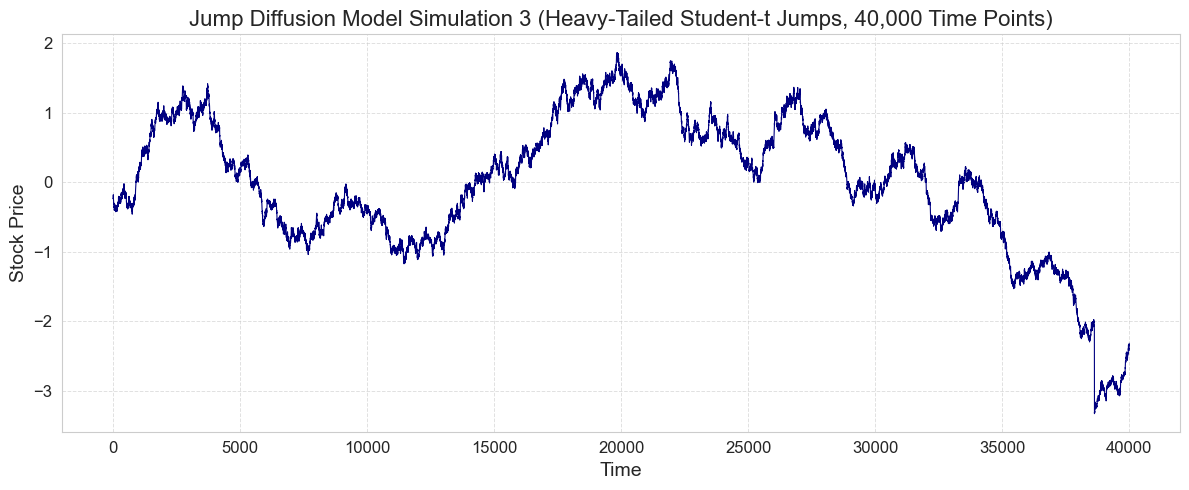

Train dataset shape: (32000,), Test dataset shape: (8000,)


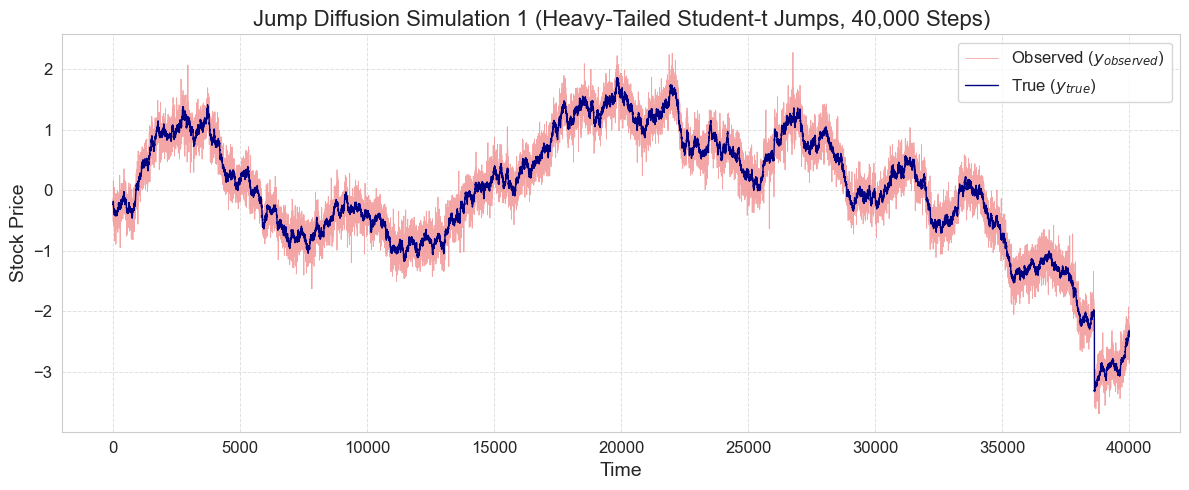

In [24]:
# Set seed for reproducibility
np.random.seed(42)

# Parameters
S0 = 100                # initial stock price
mu = 0.05               # drift
sigma = 0.2             # volatility
lamb = 0.5              # jump intensity
df_t = 2                # degrees of freedom for heavy-tailed t distribution
scale_t = 0.3           # scale parameter for t-distribution
T = 1.0                 # total time
N = 40000               # number of time steps
dt = T / N              # time step


t = np.arange(N)

# Brownian increments
dW = np.random.normal(0, np.sqrt(dt), N)
# Poisson jump component
N_jumps = np.random.poisson(lamb * dt, N)  # 0 or 1 jumps per step
J = np.random.standard_t(df_t, size=N) * scale_t   # heavy-tailed jump sizes (Student's t)
jump_component = (np.exp(J) - 1) * N_jumps

# Initialize price path
S = np.zeros(N)
S[0] = S0

for i in range(1, N):
    S[i] = S[i-1] * (1 + mu * dt + sigma * dW[i] + jump_component[i])

scaler = StandardScaler()
S_sd = scaler.fit_transform(S.reshape(-1, 1)).flatten()


data_jd_sd = pd.DataFrame({'x': t, 'y': S_sd})

# Plot
plt.figure(figsize=(12, 5))
plt.plot(data_jd_sd['x'], data_jd_sd['y'], color="navy", linewidth=0.8)

# Titles and labels
plt.title('Jump Diffusion Model Simulation 3 (Heavy-Tailed Student-t Jumps, 40,000 Time Points)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()


# Train-test split 
sigma_t = np.exp(-2 + 0.3 * np.random.normal(size=N)) 
noise = np.random.normal(0, sigma_t, size=N)
y_observed = data_jd_sd['y'] + noise 
train_size3 = int(0.8 * len(y_observed))
test_size = int(0.2 * len(y_observed))

y_train_sim3 = y_observed[:train_size3]
y_test_sim3 = y_observed[train_size3:]
y_true = data_jd_sd['y'].to_numpy()
y_true_test = data_jd_sd['y'].to_numpy()[train_size3:] 


print(f"Train dataset shape: {y_train_sim3.shape}, Test dataset shape: {y_test_sim3.shape}")

plt.figure(figsize=(12, 5))

# Plot observed series (noisy)
plt.plot(data_jd_sd['x'], y_observed, 
         color="lightcoral", linewidth=0.6, alpha=0.7, 
         label="Observed ($y_{observed}$)")

plt.plot(data_jd_sd['x'], data_jd_sd['y'], 
         color="navy", linewidth=1.0, 
         label="True ($y_{true}$)")

plt.title('Jump Diffusion Simulation 1 (Heavy-Tailed Student-t Jumps, 40,000 Steps)', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Stock Price', fontsize=14)
plt.grid(True, linestyle="--", linewidth=0.7, alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# LSTM(3 base learners)

In [25]:

tf.keras.backend.clear_session()

def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


seq_length = 15
X_train, X_test, y_train, y_test = create_sequences(y_observed, seq_length, train_ratio=0.8)

#  Model 1: Deep + tanh (long memory)

set_global_seed(42) 
model1 = Sequential([
    LSTM(256, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.1),
    LSTM(64, activation='tanh'),
    Dropout(0.1),
    Dense(1)
])
model1.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')
history1 = model1.fit(X_train, y_train, epochs=6, batch_size=16, verbose=0)
y_pred_lstm1 = model1.predict(X_test).flatten()

results_jd_lstm1 = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm1, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm1, alpha=0.1, W=1000)
print("Model 1 mean CI width:", np.mean(results_jd_lstm1['q_decaying']))
CI_lstm_decaying_model1 = results_jd_lstm1['q_decaying'] * 2


#  Model 2: Mid-depth + relu (nonlinear learner)

model2 = Sequential([
    LSTM(128, activation='elu', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.1),
    LSTM(32, activation='elu'),
    Dropout(0.1),
    Dense(1)
])
model2.compile(optimizer=Adam(learning_rate=0.0002), loss='mean_squared_error')
history2 = model2.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)
y_pred_lstm2 = model2.predict(X_test).flatten()

results_jd_lstm2 = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm2, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm2, alpha=0.1, W=1000)
print("Model 2 mean CI width:", np.mean(results_jd_lstm2['q_decaying']))
CI_lstm_decaying_model2 = results_jd_lstm2['q_decaying'] * 2


#  Model 3: Compact + relu (fast short-term learner)
model3 = Sequential([
    LSTM(32, activation='relu', input_shape=(seq_length, 1)),
    Dropout(0.1),
    Dense(1)
])
model3.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
history3 = model3.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
y_pred_lstm3 = model3.predict(X_test).flatten()

results_jd_lstm3 = compute_coverage_metrics(y_true_test[seq_length:], y_pred_lstm3, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_jd_lstm3, alpha=0.1, W=1000)
print("Model 3 mean CI width:", np.mean(results_jd_lstm3['q_decaying']))
CI_lstm_decaying_model3 = results_jd_lstm3['q_decaying'] * 2


KeyboardInterrupt: 

In [ ]:
# coverage checks

print(f"coverage for lstm1", np.mean(results_jd_lstm1['observed_coverages_decaying']))
print(f"coverage for lstm2", np.mean(results_jd_lstm2['observed_coverages_decaying']))
print(f"coverage for lstm3", np.mean(results_jd_lstm3['observed_coverages_decaying']))

CI_lstm_decaying_model1 = results_jd_lstm1['q_decaying'] * 2
print(np.mean(CI_lstm_decaying_model1))

CI_lstm_decaying_model2 = results_jd_lstm2['q_decaying'] * 2
print(np.mean(CI_lstm_decaying_model2))

CI_lstm_decaying_model3 = results_jd_lstm3['q_decaying'] * 2
print(np.mean(CI_lstm_decaying_model3))

coverage for lstm1 0.8901690670006261
coverage for lstm2 0.8969317470256731
coverage for lstm3 0.8948027551659361
0.4830325815654253
0.2431610543706772
0.32688814079377726


# Simple Average

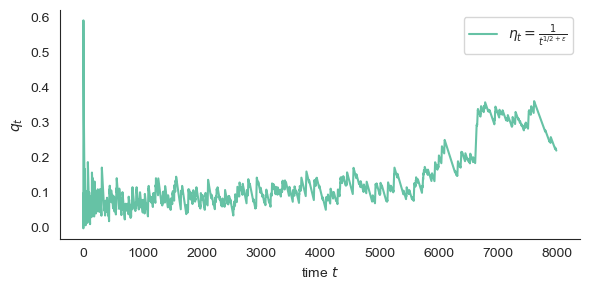

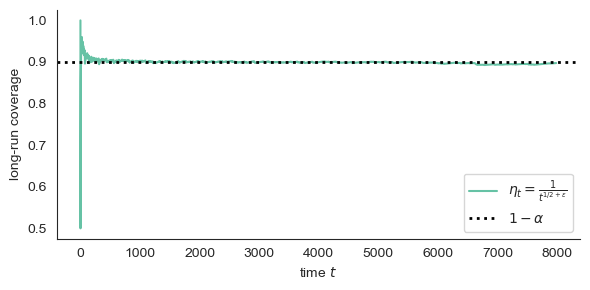

0.14361489395532237


In [ ]:
y_sa_pred_ensemble = simple_average_ensemble([y_pred_lstm1, y_pred_lstm2, y_pred_lstm3])
results_sa_lstm = compute_coverage_metrics(y_true_test[seq_length:], y_sa_pred_ensemble, alpha=0.1, epsilon=0.1, W=1000, C=1)
plot_coverage_results(results_sa_lstm, alpha=0.1, W=1000)
print(np.mean(results_sa_lstm['q_decaying']))
CI_sa_decaying = results_sa_lstm['q_decaying'] * 2

# Super Learner

Fold 0: train=5335, val=5333
Epoch 1/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0579
Epoch 2/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0295
Epoch 3/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0285
Epoch 4/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0288
Epoch 5/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0281
Epoch 6/6
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0284
167/167 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Epoch 1/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0816
Epoch 2/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0297
Epoch 3/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0288
Epoch 4/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0280
Epoch 5/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0281
Epoch 6/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0284
Epoch 7/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0283
Epoch 8/10
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss:

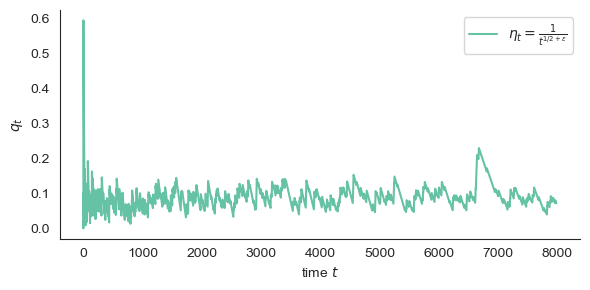

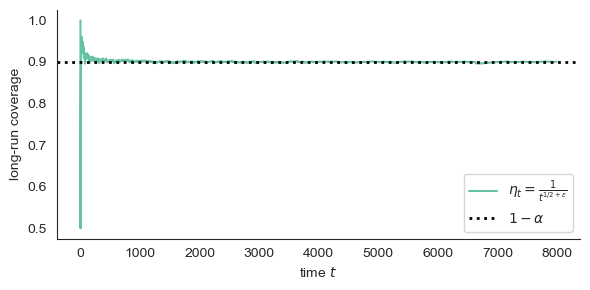

coverage for sl 0.9005635566687539


In [ ]:
set_global_seed(42)
def optimize_weights(X, y, alpha1=0.0, alpha2=0.0):
    init_phi = np.ones(X.shape[1]) / X.shape[1]
    def mse_loss(phi):
        y_pred = X @ phi
        mse = np.mean((y - y_pred) ** 2)
        l1 = alpha1 * np.sum(np.abs(phi))
        l2 = alpha2 * np.sum(phi**2)
        return mse + l1 + l2
    constraints = [{'type': 'eq', 'fun': lambda phi: np.sum(phi) - 1}]
    bounds = [(0, 1)] * X.shape[1]
    result = minimize(mse_loss, init_phi, bounds=bounds, constraints=constraints)
    return result.x

def build_lstm_model(model_id, seq_length):
    set_global_seed(42)
    if model_id == 1:   # Deep + tanh
        return Sequential([
                LSTM(256, activation='tanh', return_sequences=True, input_shape=(seq_length, 1)),
                Dropout(0.1),
                LSTM(64, activation='tanh'),
                Dropout(0.1),
                Dense(1)
                ]), Adam(learning_rate=0.0005), 6, 16

    elif model_id == 2: # Shallow + relu
        return Sequential([
                    LSTM(128, activation='elu', return_sequences=True, input_shape=(seq_length, 1)),
                    Dropout(0.1),
                    LSTM(32, activation='elu'),
                    Dropout(0.1),
                    Dense(1)
        ]), Adam(learning_rate=0.0002), 10, 16

    elif model_id == 3: # Compact + relu
        return Sequential([
                    LSTM(32, activation='relu', input_shape=(seq_length, 1)),
                    Dropout(0.1),
                    Dense(1)
        ]), Adam(learning_rate=0.001), 10, 32

def super_learner_lstm(y, seq_length=15, n_splits=5):
    """
    Super Learner with 3 fixed LSTM base learners (your three definitions).
    """
    # Build sequences
    X_all, _, y_all, _ = create_sequences(y, seq_length, train_ratio=0.8)
    n_total = len(y)
    train_size = int(0.8 * n_total)
    y_train, y_test = y[:train_size], y[train_size:]

    tscv = TimeSeriesSplit(n_splits=n_splits)
    meta_features = np.full((train_size - seq_length, 3), np.nan)

    for fold, (train_idx, val_idx) in enumerate(tscv.split(y_train)):
        print(f"Fold {fold}: train={len(train_idx)}, val={len(val_idx)}")
        # Map sequence indices
        tr_rows = train_idx[train_idx >= seq_length] - seq_length
        va_rows = val_idx[val_idx >= seq_length] - seq_length

        X_tr, y_tr = X_all[tr_rows], y_all[tr_rows]
        X_va, y_va = X_all[va_rows], y_all[va_rows]

        for i in range(3):
            model, opt, epochs, batch_size = build_lstm_model(i+1, seq_length)
            model.compile(optimizer=opt, loss='mse')
            model.fit(X_tr, y_tr, epochs=epochs, batch_size=batch_size)
            preds_val = model.predict(X_va).flatten()
            meta_features[va_rows, i] = preds_val

    valid_rows = ~np.isnan(meta_features).any(axis=1)
    X_meta = meta_features[valid_rows]
    y_meta = y_train[seq_length:][valid_rows]
    # meta-learner weights 
    meta_weights = optimize_weights(X_meta, y_meta)
    print("First meta-learner weights:", meta_weights)

    # Retrain on full dataset 
    X_train_full, X_test_full, y_train_full, y_test_full = create_sequences(y, seq_length, train_ratio=0.8)
    full_preds = []

    for i in range(3):
        model, opt, epochs, batch_size = build_lstm_model(i+1, seq_length)
        model.compile(optimizer=opt, loss='mse')
        model.fit(X_train_full, y_train_full, epochs=epochs, batch_size=batch_size)
        preds = model.predict(X_test_full).flatten()
        full_preds.append(preds)

    X_test_meta = np.column_stack(full_preds)
    T_test = len(y_test_full) 
    super_preds = np.zeros(T_test)
    weights_hist = np.zeros((T_test, 3))
    w = meta_weights.copy() 
    # NNLS with online updating 
    for t in range(T_test):
        # update weight using past only (0..t-1)
        if t > 0:
            w = optimize_weights(X_test_meta[:t], y_test_full[:t])

        super_preds[t] = X_test_meta[t] @ w
        weights_hist[t] = w

    return super_preds, weights_hist


y = y_observed.to_numpy()
super_preds_lstm, weights_hist_lstm = super_learner_lstm(y, seq_length=15, n_splits=5)
results_super_lstm = compute_coverage_metrics(
    y_true_test[seq_length:], super_preds_lstm,
    alpha=0.1, epsilon=0.1, W=1000, C=1
)
plot_coverage_results(results_super_lstm, alpha=0.1, W=1000)
print(f"coverage for sl", np.mean(results_super_lstm['observed_coverages_decaying']))

# Comparison

0.18239717149960838


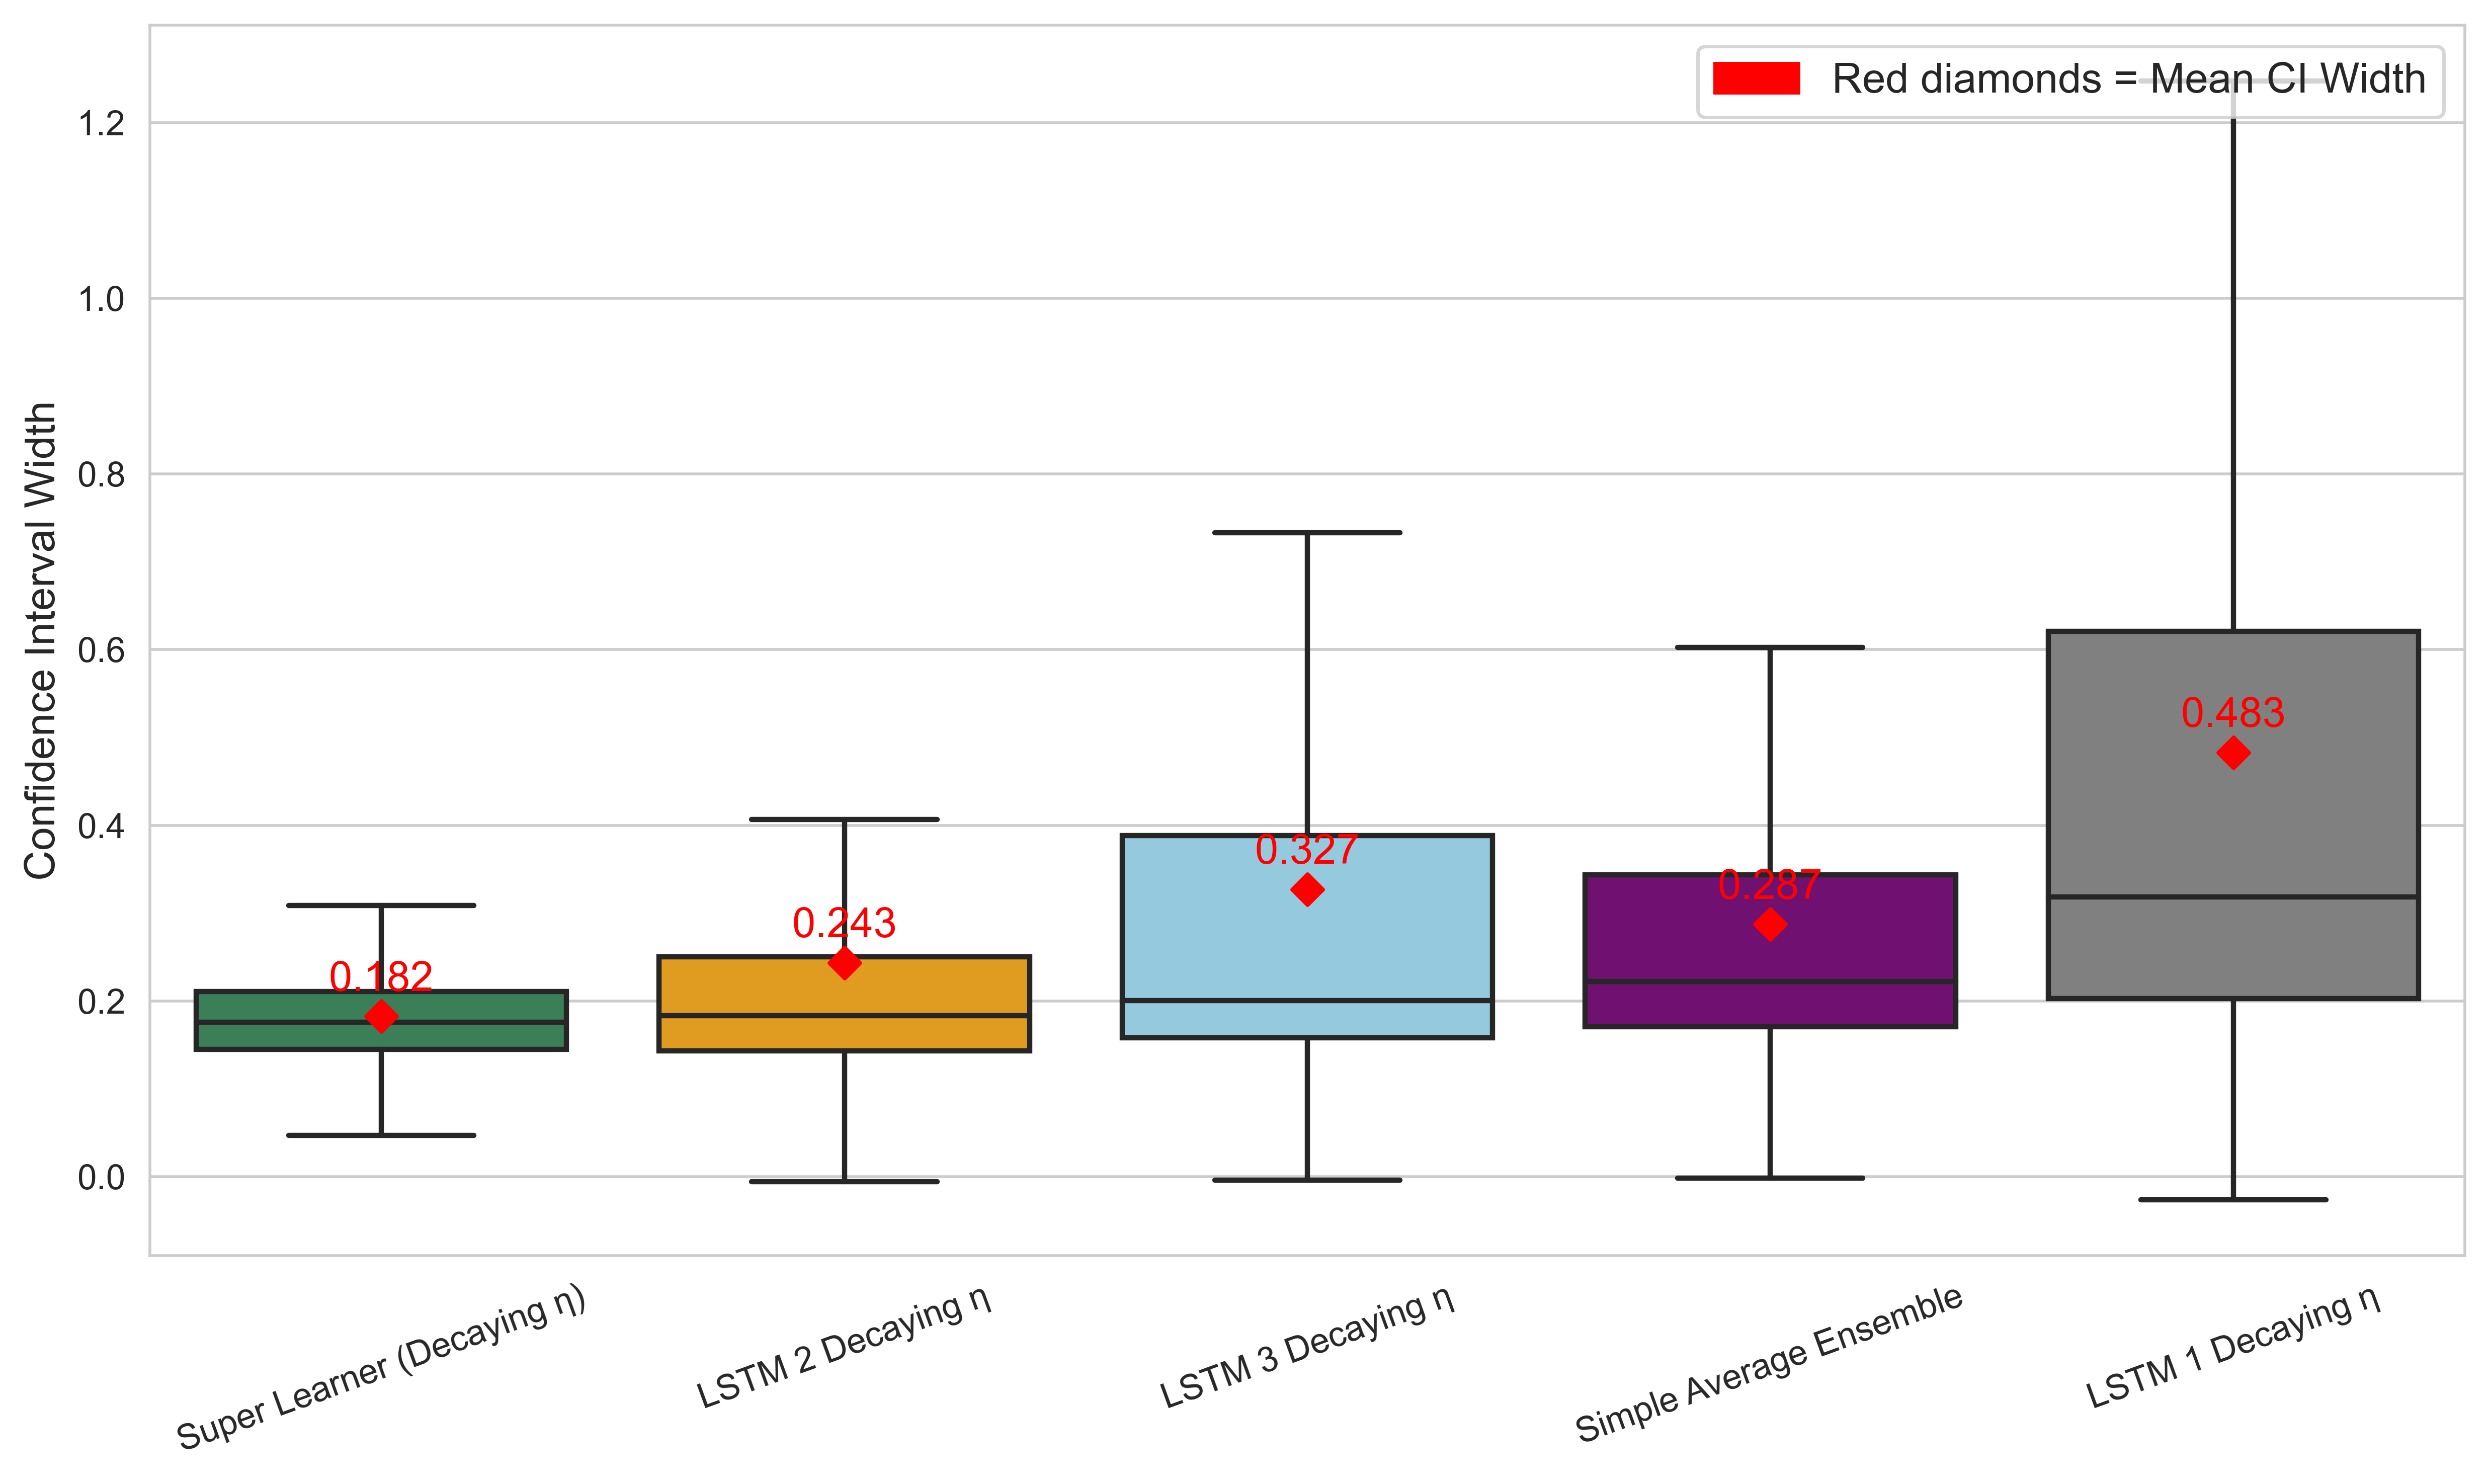

In [ ]:
CI_sp_decaying = results_super_lstm['q_decaying'] * 2 
print(np.mean(CI_sp_decaying))

data_dict = {
    "LSTM 1 Decaying η": CI_lstm_decaying_model1,
    "LSTM 2 Decaying η": CI_lstm_decaying_model2,
    "LSTM 3 Decaying η": CI_lstm_decaying_model3,
    "Simple Average Ensemble": CI_sa_decaying,
    "Super Learner (Decaying η)": CI_sp_decaying
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")
order = df_long.groupby("Method")["CI Width"].median().sort_values().index

plt.figure(figsize=(10, 6), dpi=500)
sns.set_style("whitegrid")
palette = {
    "LSTM 1 Decaying η": "gray",
    "LSTM 2 Decaying η": "orange",
    "LSTM 3 Decaying η": "skyblue",
    "Simple Average Ensemble": "purple",
    "Super Learner (Decaying η)": "seagreen"
}

ax = sns.boxplot(x="Method", y="CI Width", data=df_long, order=order,
                 palette=palette, showfliers=False)

means = df_long.groupby("Method")["CI Width"].mean()
for i, method in enumerate(order):
    ax.scatter(i, means[method], color="red", marker="D", s=40, zorder=3)
    ax.text(i, means[method]+0.02, f"{means[method]:.3f}",
            ha='center', va='bottom', fontsize=12, color="red")

mean_patch = mpatches.Patch(color='red', label='Red diamonds = Mean CI Width')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [mean_patch], labels + ['Red diamonds = Mean CI Width'],
          loc='upper right', fontsize=12, frameon=True)

#plt.title("Sim1: Comparison of Confidence Interval Widths Across Methods", fontsize=14)
plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("lstm1_CI_comparison.png", dpi=500, bbox_inches="tight")
plt.show()


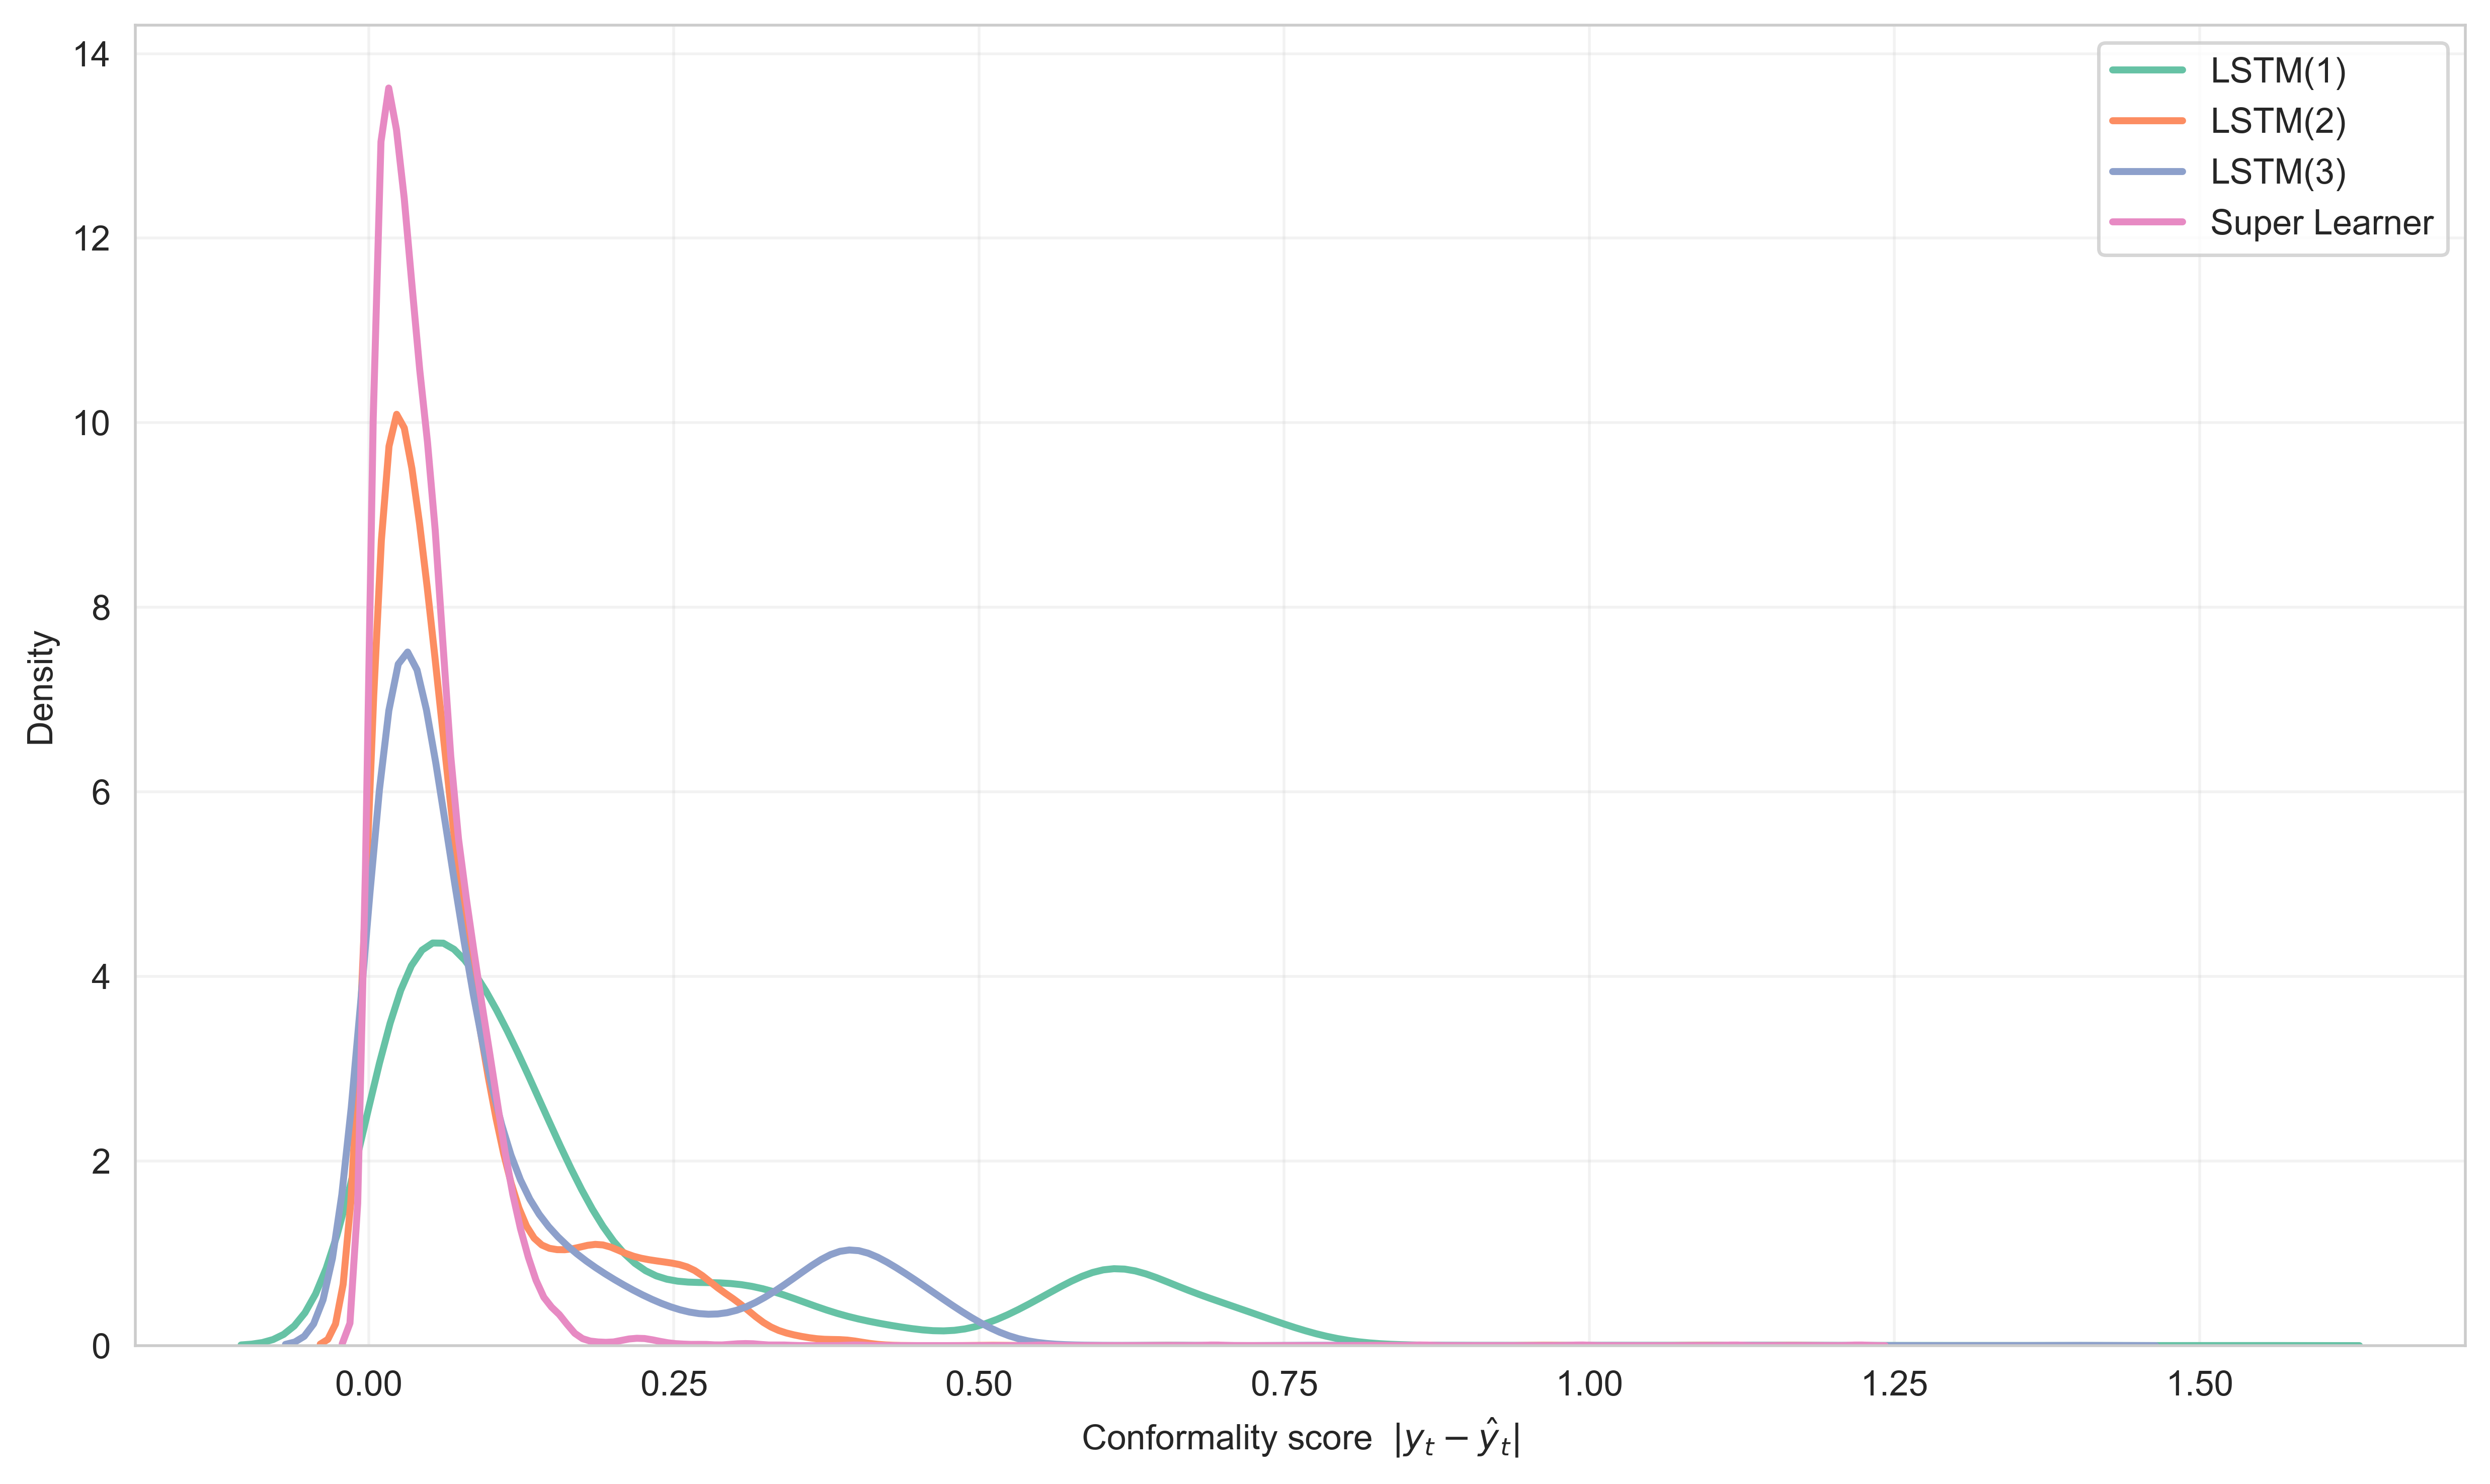

In [ ]:

# Conformality scores
score_garch1 = np.abs(y_true_test[seq_length:] - y_pred_lstm1)
score_garch2 = np.abs(y_true_test[seq_length:] - y_pred_lstm2)
score_garch3 = np.abs(y_true_test[seq_length:] - y_pred_lstm3)
score_sl = np.abs(y_true_test[seq_length:] - super_preds_lstm)

plt.figure(figsize=(10, 6), dpi=500)

sns.kdeplot(score_garch1, label="LSTM(1)", linewidth=2)
sns.kdeplot(score_garch2, label="LSTM(2)", linewidth=2)
sns.kdeplot(score_garch3, label="LSTM(3)", linewidth=2)
sns.kdeplot(score_sl, label="Super Learner", linewidth=2)

plt.xlabel("Conformality score  $|y_t - \hat y_t|$")
plt.ylabel("Density")
#plt.title("Sim1 (LSTM): Density of Conformality Scores")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("lstm1_score_density.png", dpi=500, bbox_inches="tight")
plt.show()

# Coma 

## adahedge

### coma v.s. sl 

Mean deterministic coverage: 0.8964308077645585
Mean randomized coverage: 0.8958046336881653
Mean CI width — COMA (rand): 0.24287769687478472
Mean CI width — Super Learner: 0.18239717149960838


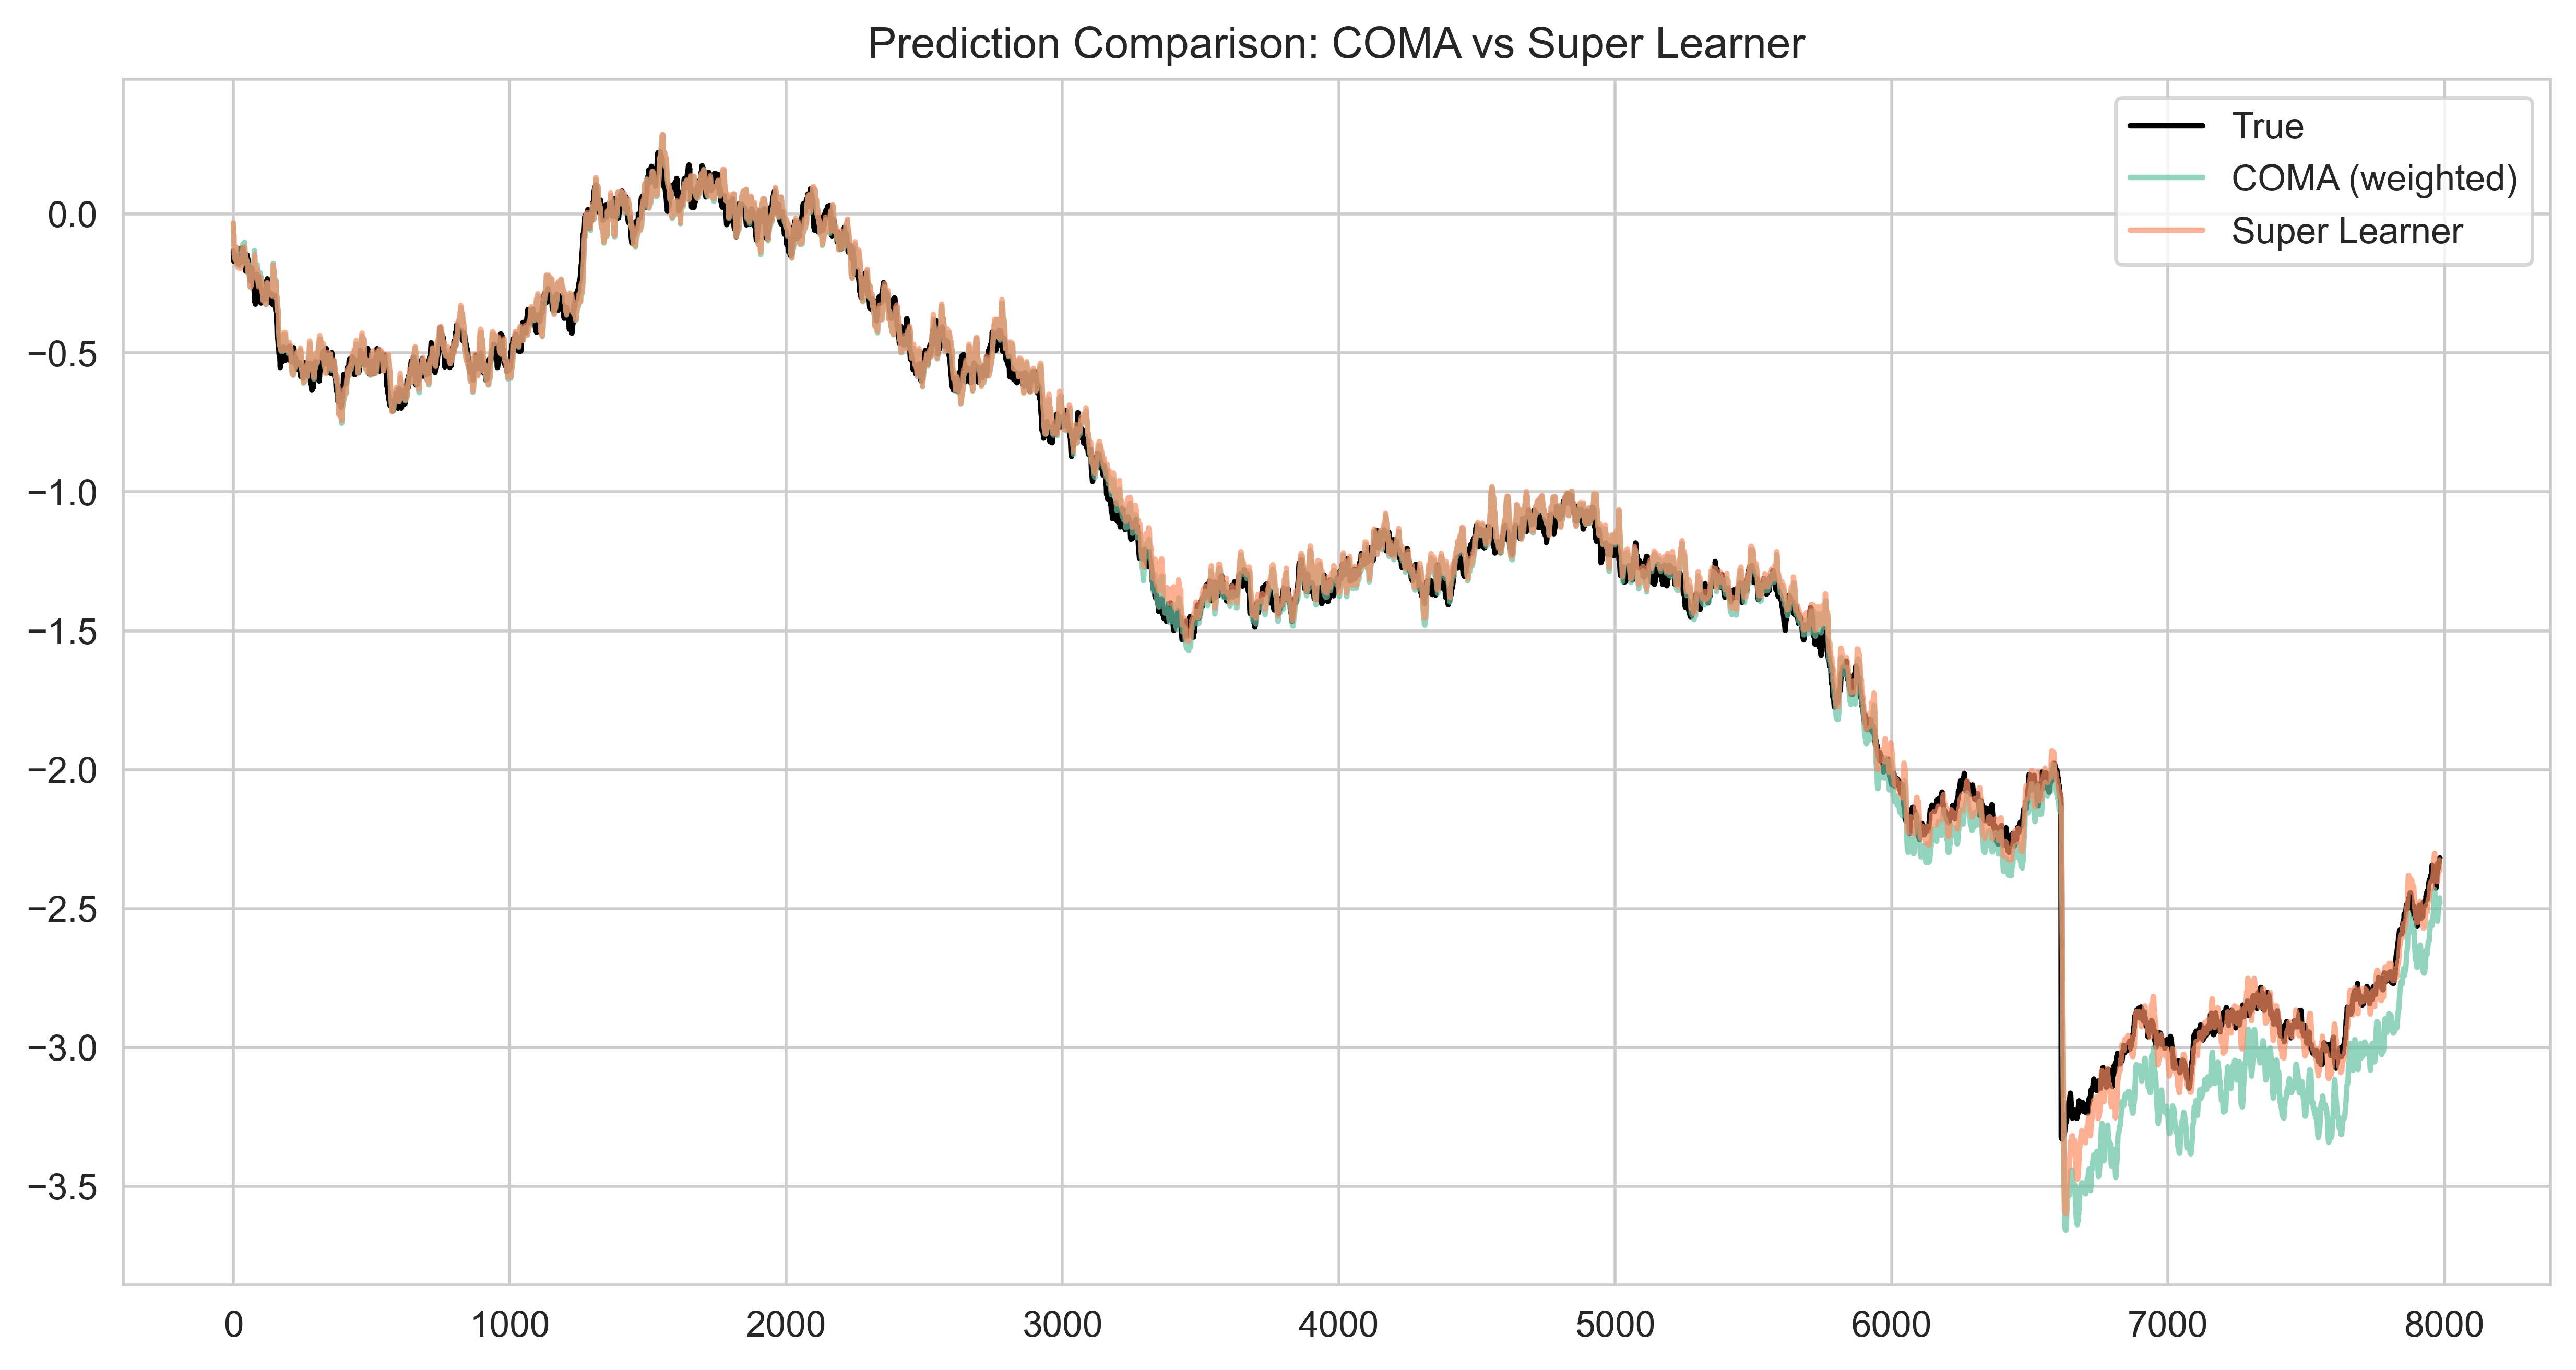

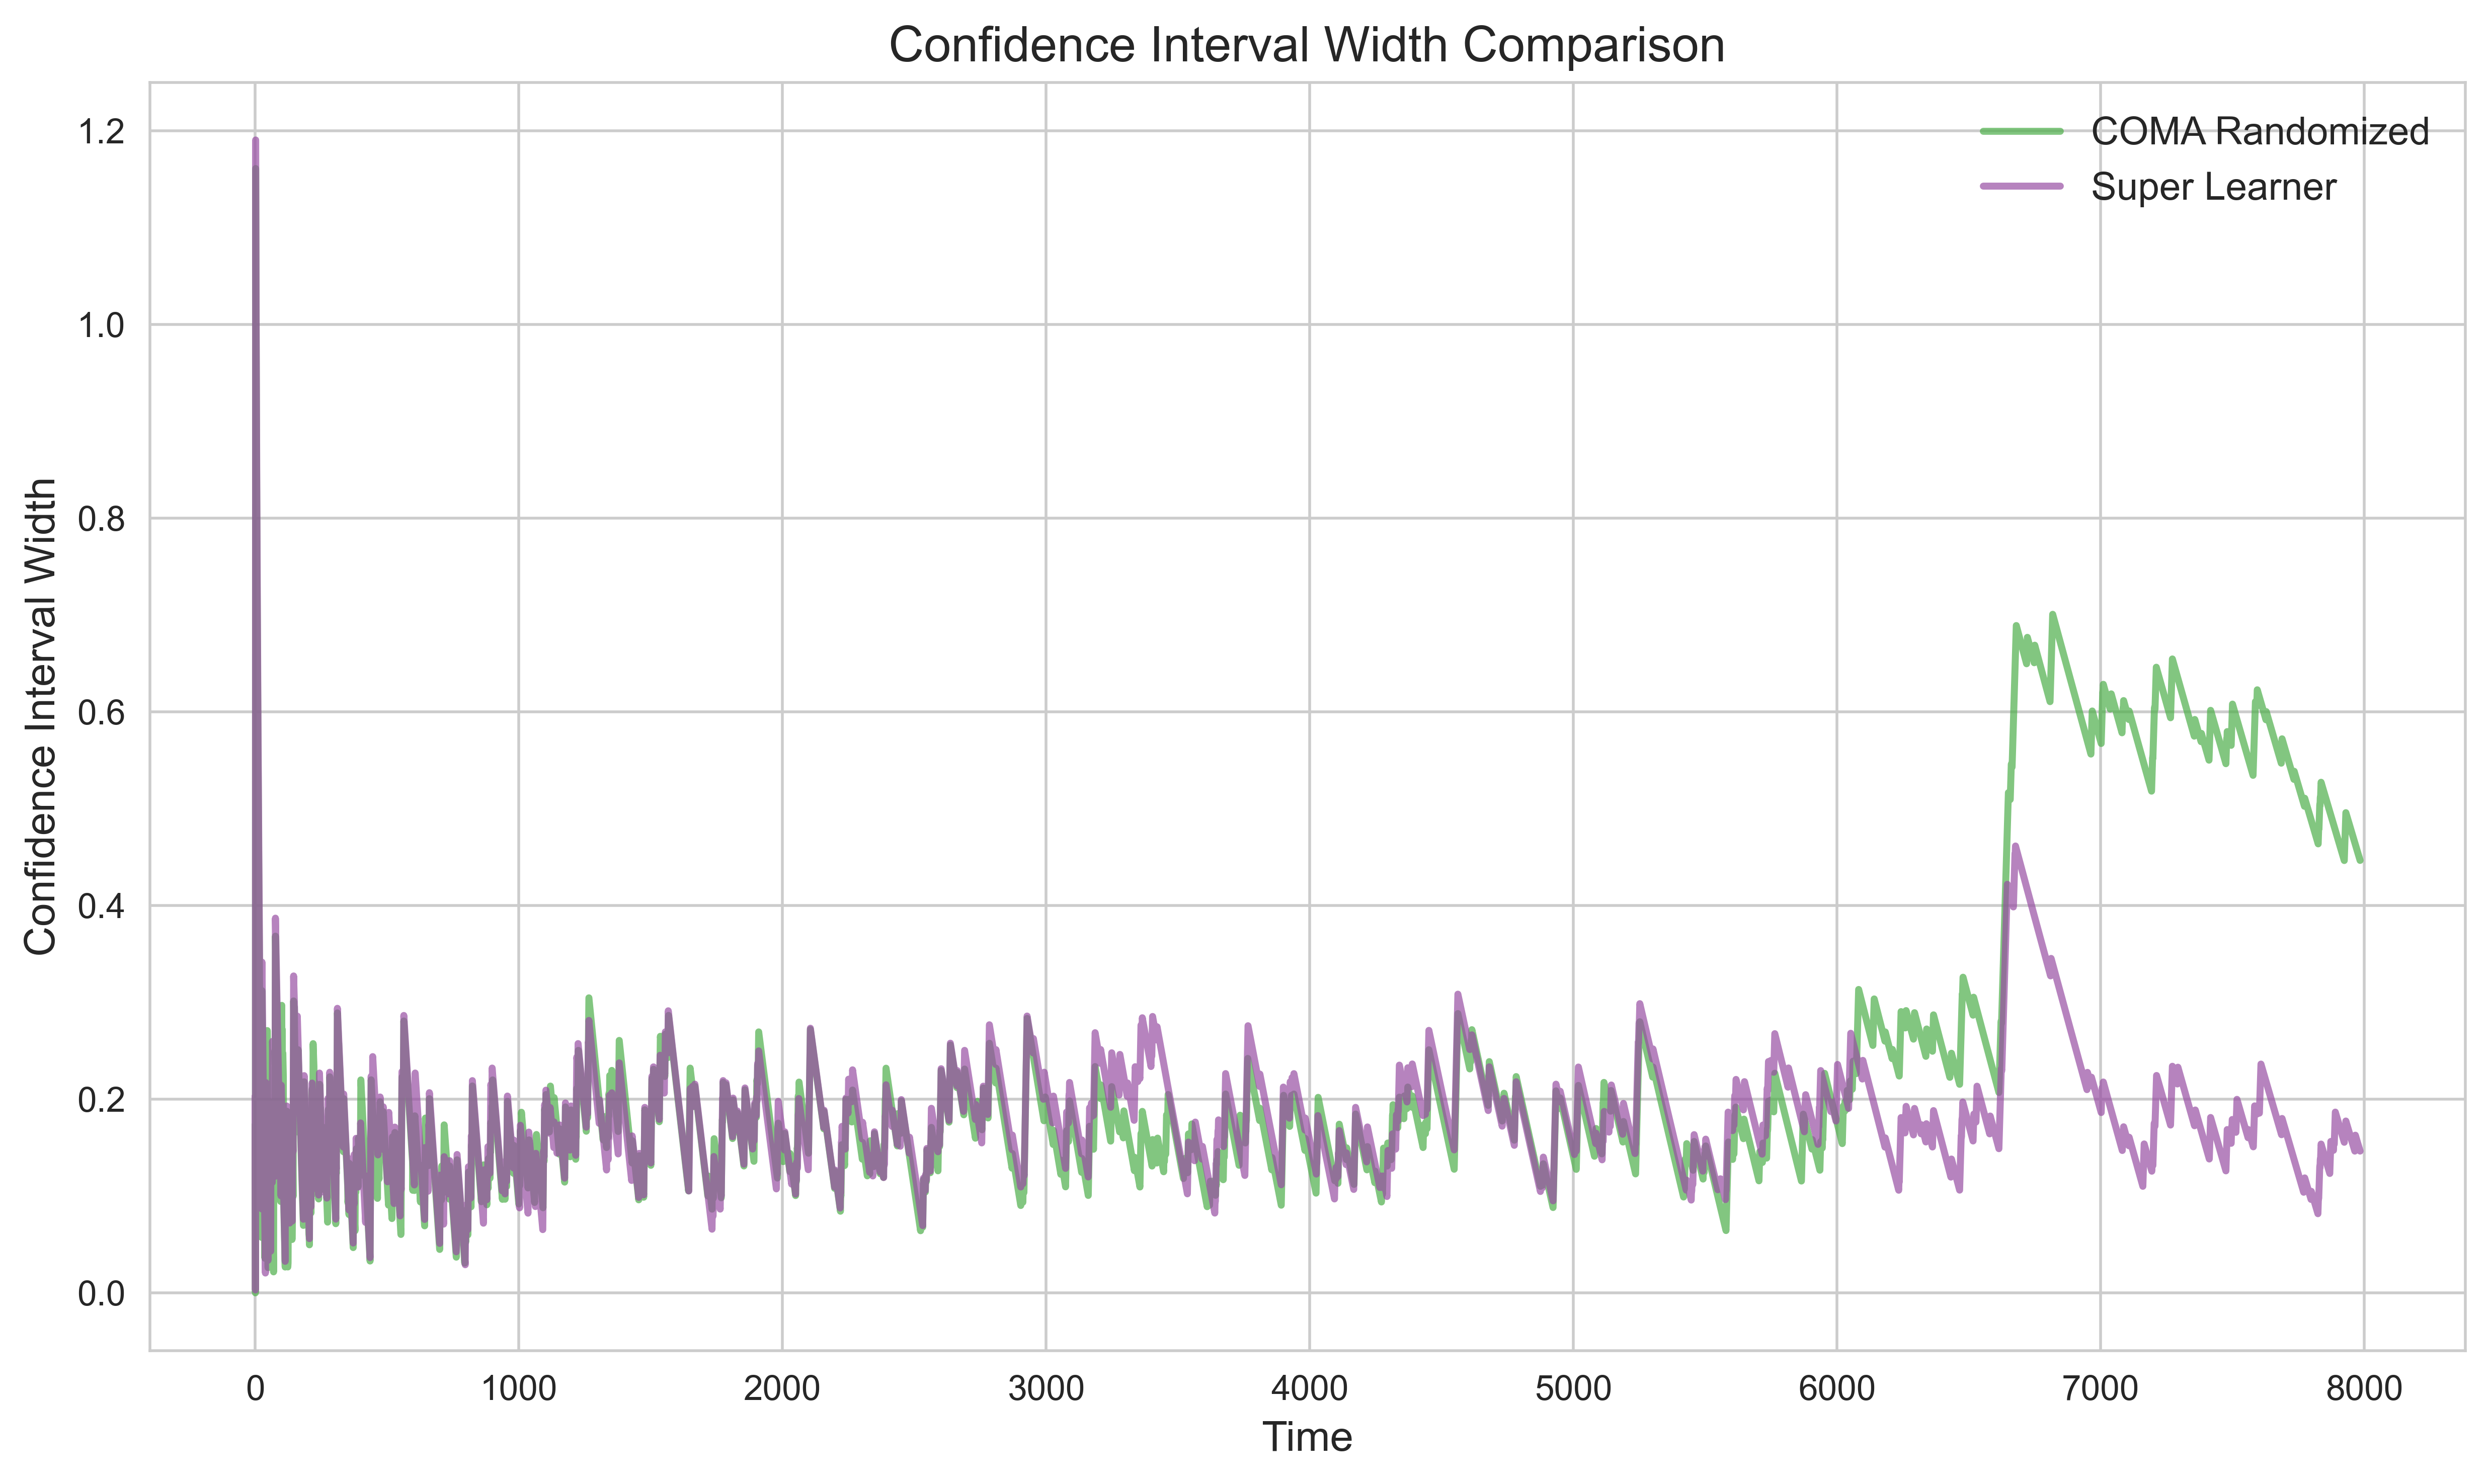

In [33]:
colors = sns.color_palette("Set1", 4)
min_len = min(
    len(results_jd_lstm1['q_decaying']),
    len(results_jd_lstm2['q_decaying']),
    len(results_jd_lstm3['q_decaying']),
    len(CI_sp_decaying),
    len(y_true_test)
)

ci_matrix = np.column_stack([
    CI_lstm_decaying_model1[-min_len:],
    CI_lstm_decaying_model2[-min_len:],
    CI_lstm_decaying_model3[-min_len:]
])
adahedAlg = adahedge(loss_matrix=ci_matrix)

intervals_lstm1 = np.column_stack([
    y_pred_lstm1[-min_len:] 
    - results_jd_lstm1['q_decaying'][-min_len:],
    y_pred_lstm1[-min_len:] 
    + results_jd_lstm1['q_decaying'][-min_len:]
])

intervals_lstm2 = np.column_stack([
    y_pred_lstm2[-min_len:] - results_jd_lstm2['q_decaying'][-min_len:],
    y_pred_lstm2[-min_len:] + results_jd_lstm2['q_decaying'][-min_len:]
])

intervals_lstm3 = np.column_stack([
    y_pred_lstm3[-min_len:] - results_jd_lstm3['q_decaying'][-min_len:],
    y_pred_lstm3[-min_len:] + results_jd_lstm3['q_decaying'][-min_len:]
])


intervals_list_plain = [intervals_lstm1, intervals_lstm2, intervals_lstm3]
weights_plain = adahedAlg["weights"]


y_test_aligned = y_true_test[-min_len:]


result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)

print("Mean deterministic coverage:", result_plain["mean_m_cov"])
print("Mean randomized coverage:", result_plain["mean_wm_cov"])


pi_wm  = result_plain["pi_wm"]

coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm])

CI_super_decaying = CI_sp_decaying[-min_len:]

print("Mean CI width — COMA (rand):", np.nanmean(coma_width_rand))
print("Mean CI width — Super Learner:", np.mean(CI_super_decaying))

base_preds_matrix = np.column_stack([
    y_pred_lstm1[-min_len:],
    y_pred_lstm2[-min_len:],
    y_pred_lstm3[-min_len:]
])

coma_preds_weighted = np.sum(base_preds_matrix * weights_plain, axis=1)

plt.figure(figsize=(12, 6), dpi=500)
plt.plot(y_test_aligned, label="True", color="black")
plt.plot(coma_preds_weighted, label="COMA (weighted)", alpha=0.7)
plt.plot(super_preds_lstm[-min_len:], label="Super Learner", alpha=0.7)
plt.legend()
plt.title("Prediction Comparison: COMA vs Super Learner")
plt.show()

plt.figure(figsize=(10, 6), dpi=500)

plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha = 0.7, color=colors[2])
plt.plot(CI_super_decaying, label='Super Learner', linewidth=2, alpha = 0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

#### smooth 

Mean CI width — COMA(base, rand): 0.22742051436191182
Mean CI width — SL: 0.1846952724507194


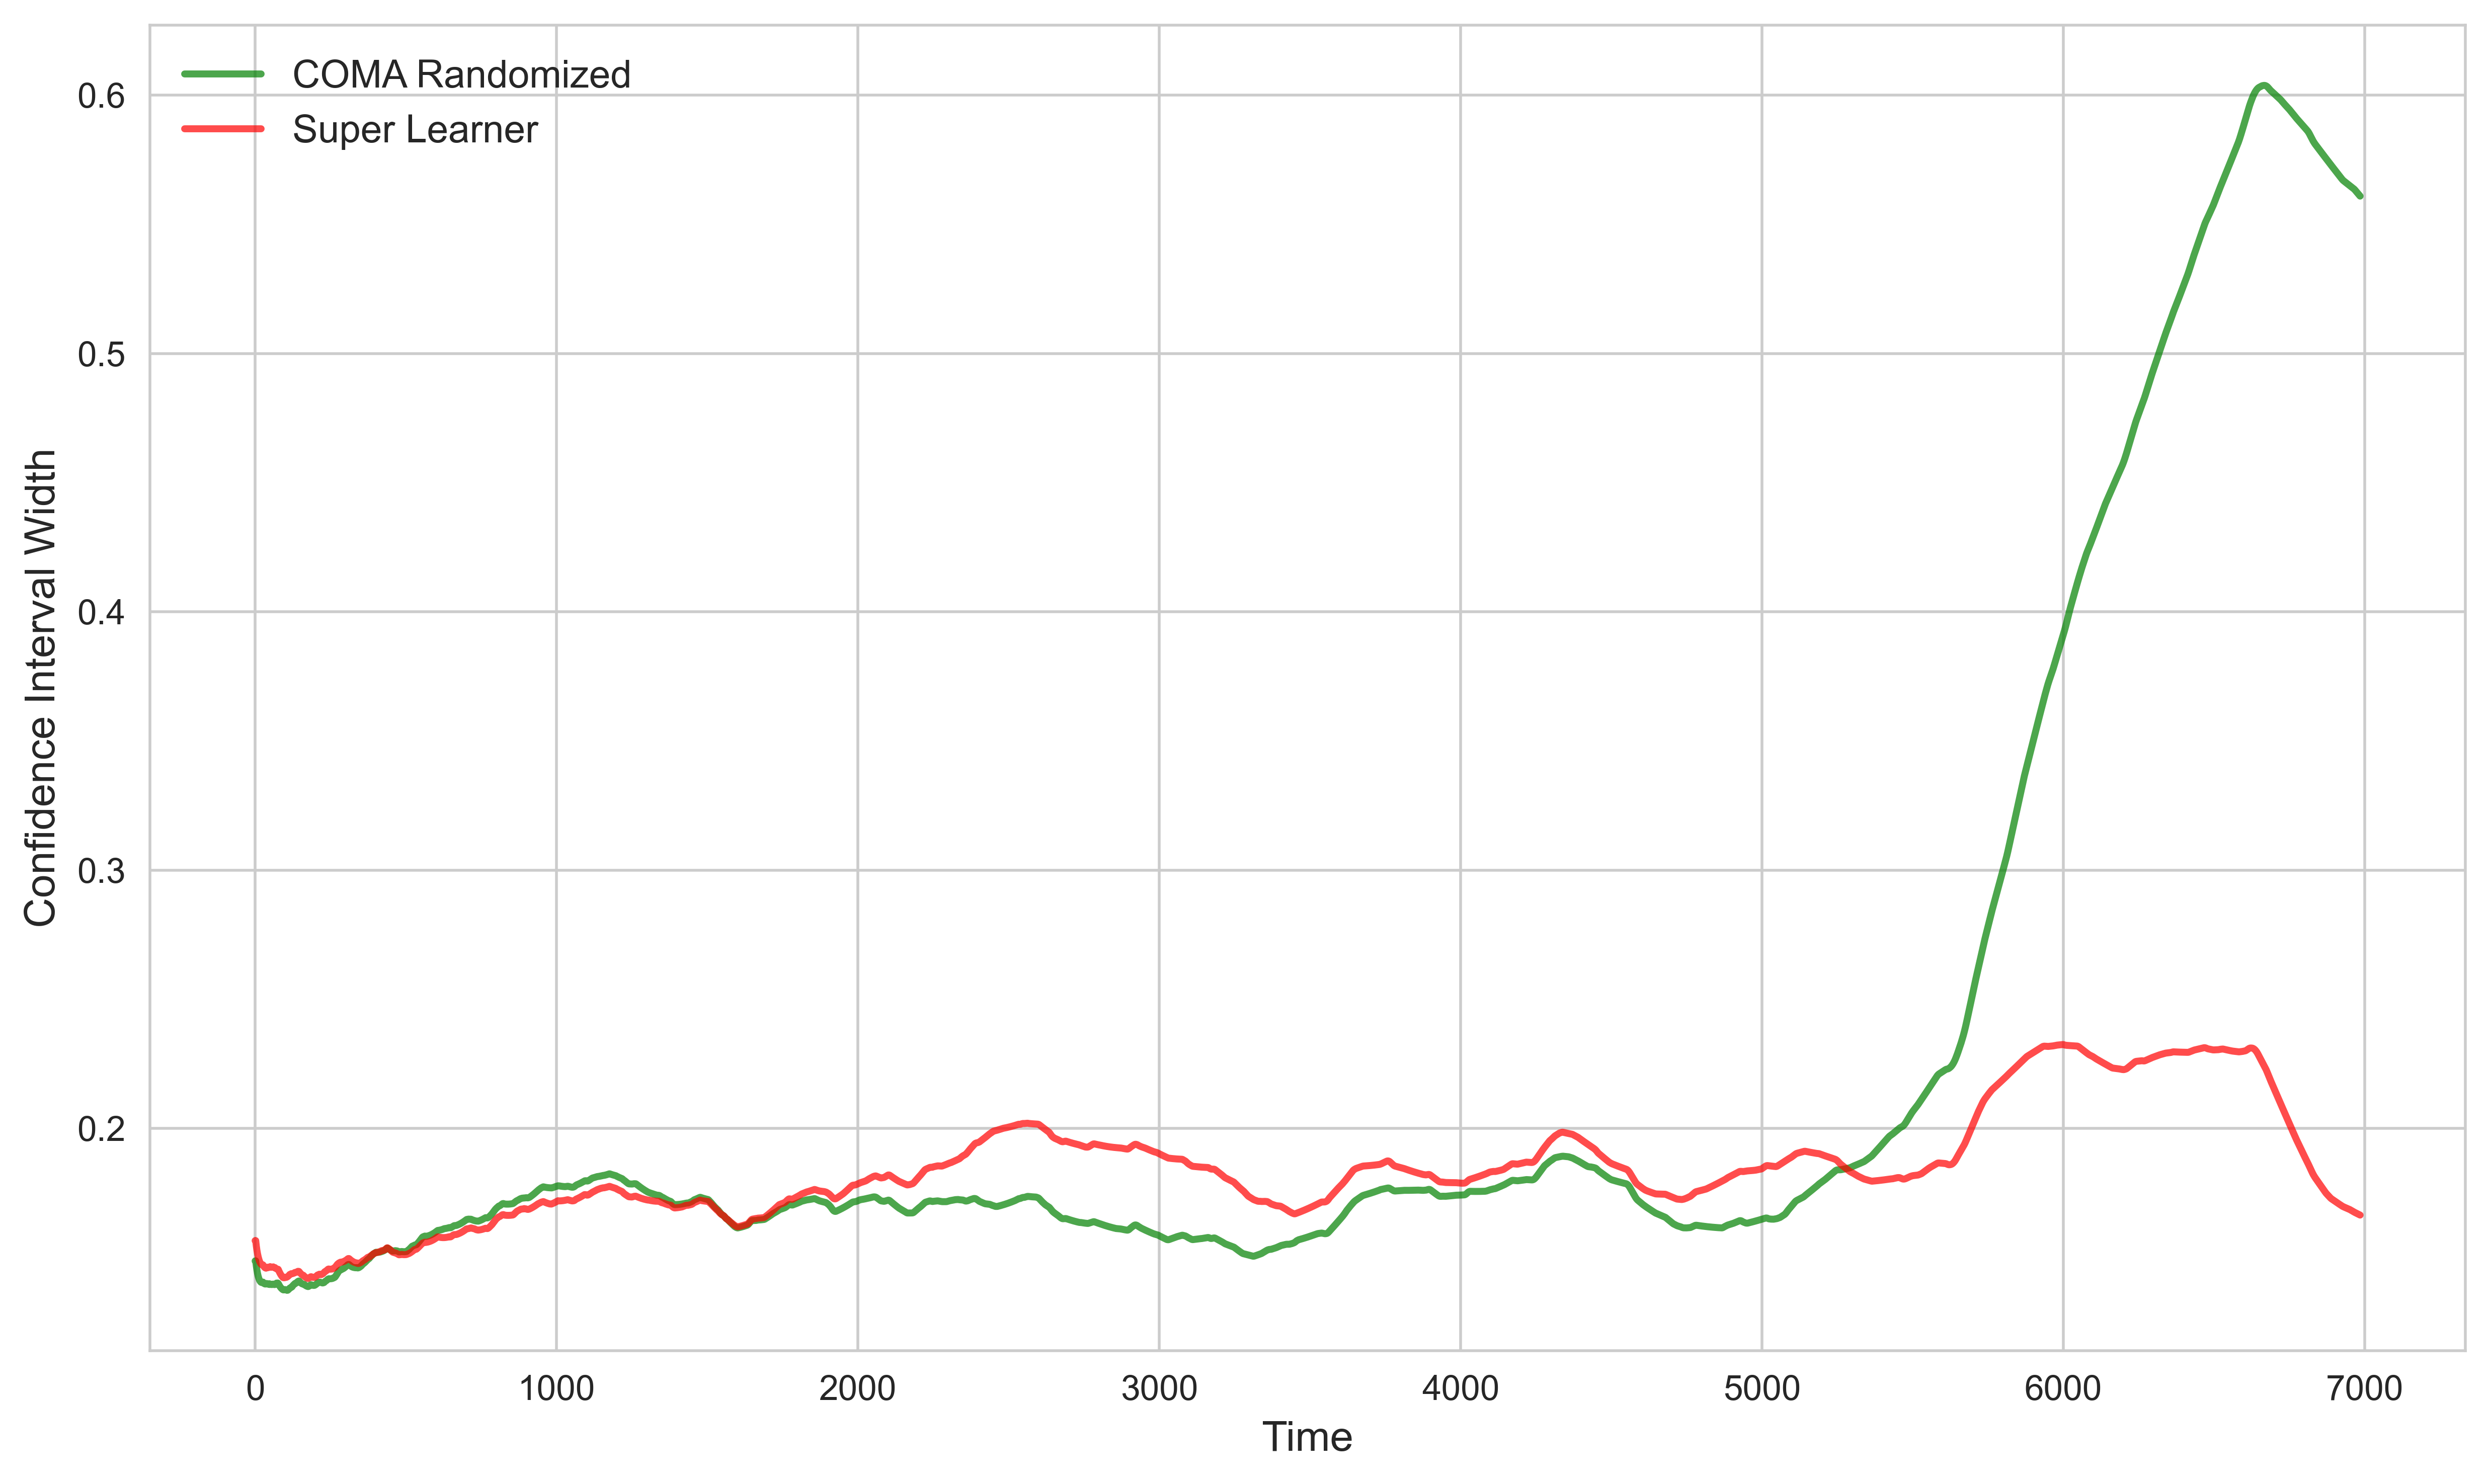

In [34]:

coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
sl_smooth = smooth_series(CI_super_decaying, window=1000)   

print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand_smooth))
print("Mean CI width — SL:", np.nanmean(sl_smooth))

plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA Randomized', linewidth=2, alpha = 0.7, color='green')
plt.plot(sl_smooth, label='Super Learner', linewidth=2, alpha = 0.7, color='red')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
#plt.title("Sim1 (LSTM, Adahedge, Smoothed): CI Widths — COMA(base) vs Super Learner", fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper left')
plt.tight_layout()
plt.savefig("lstm1_adahedge_smooth_line_base.png", dpi=500, bbox_inches="tight")
plt.show()


### coma v.s. coma+sl

Mean randomized coverage: 0.8956793988728866
Mean CI width — COMA (rand) + SL: 0.1819024725131762


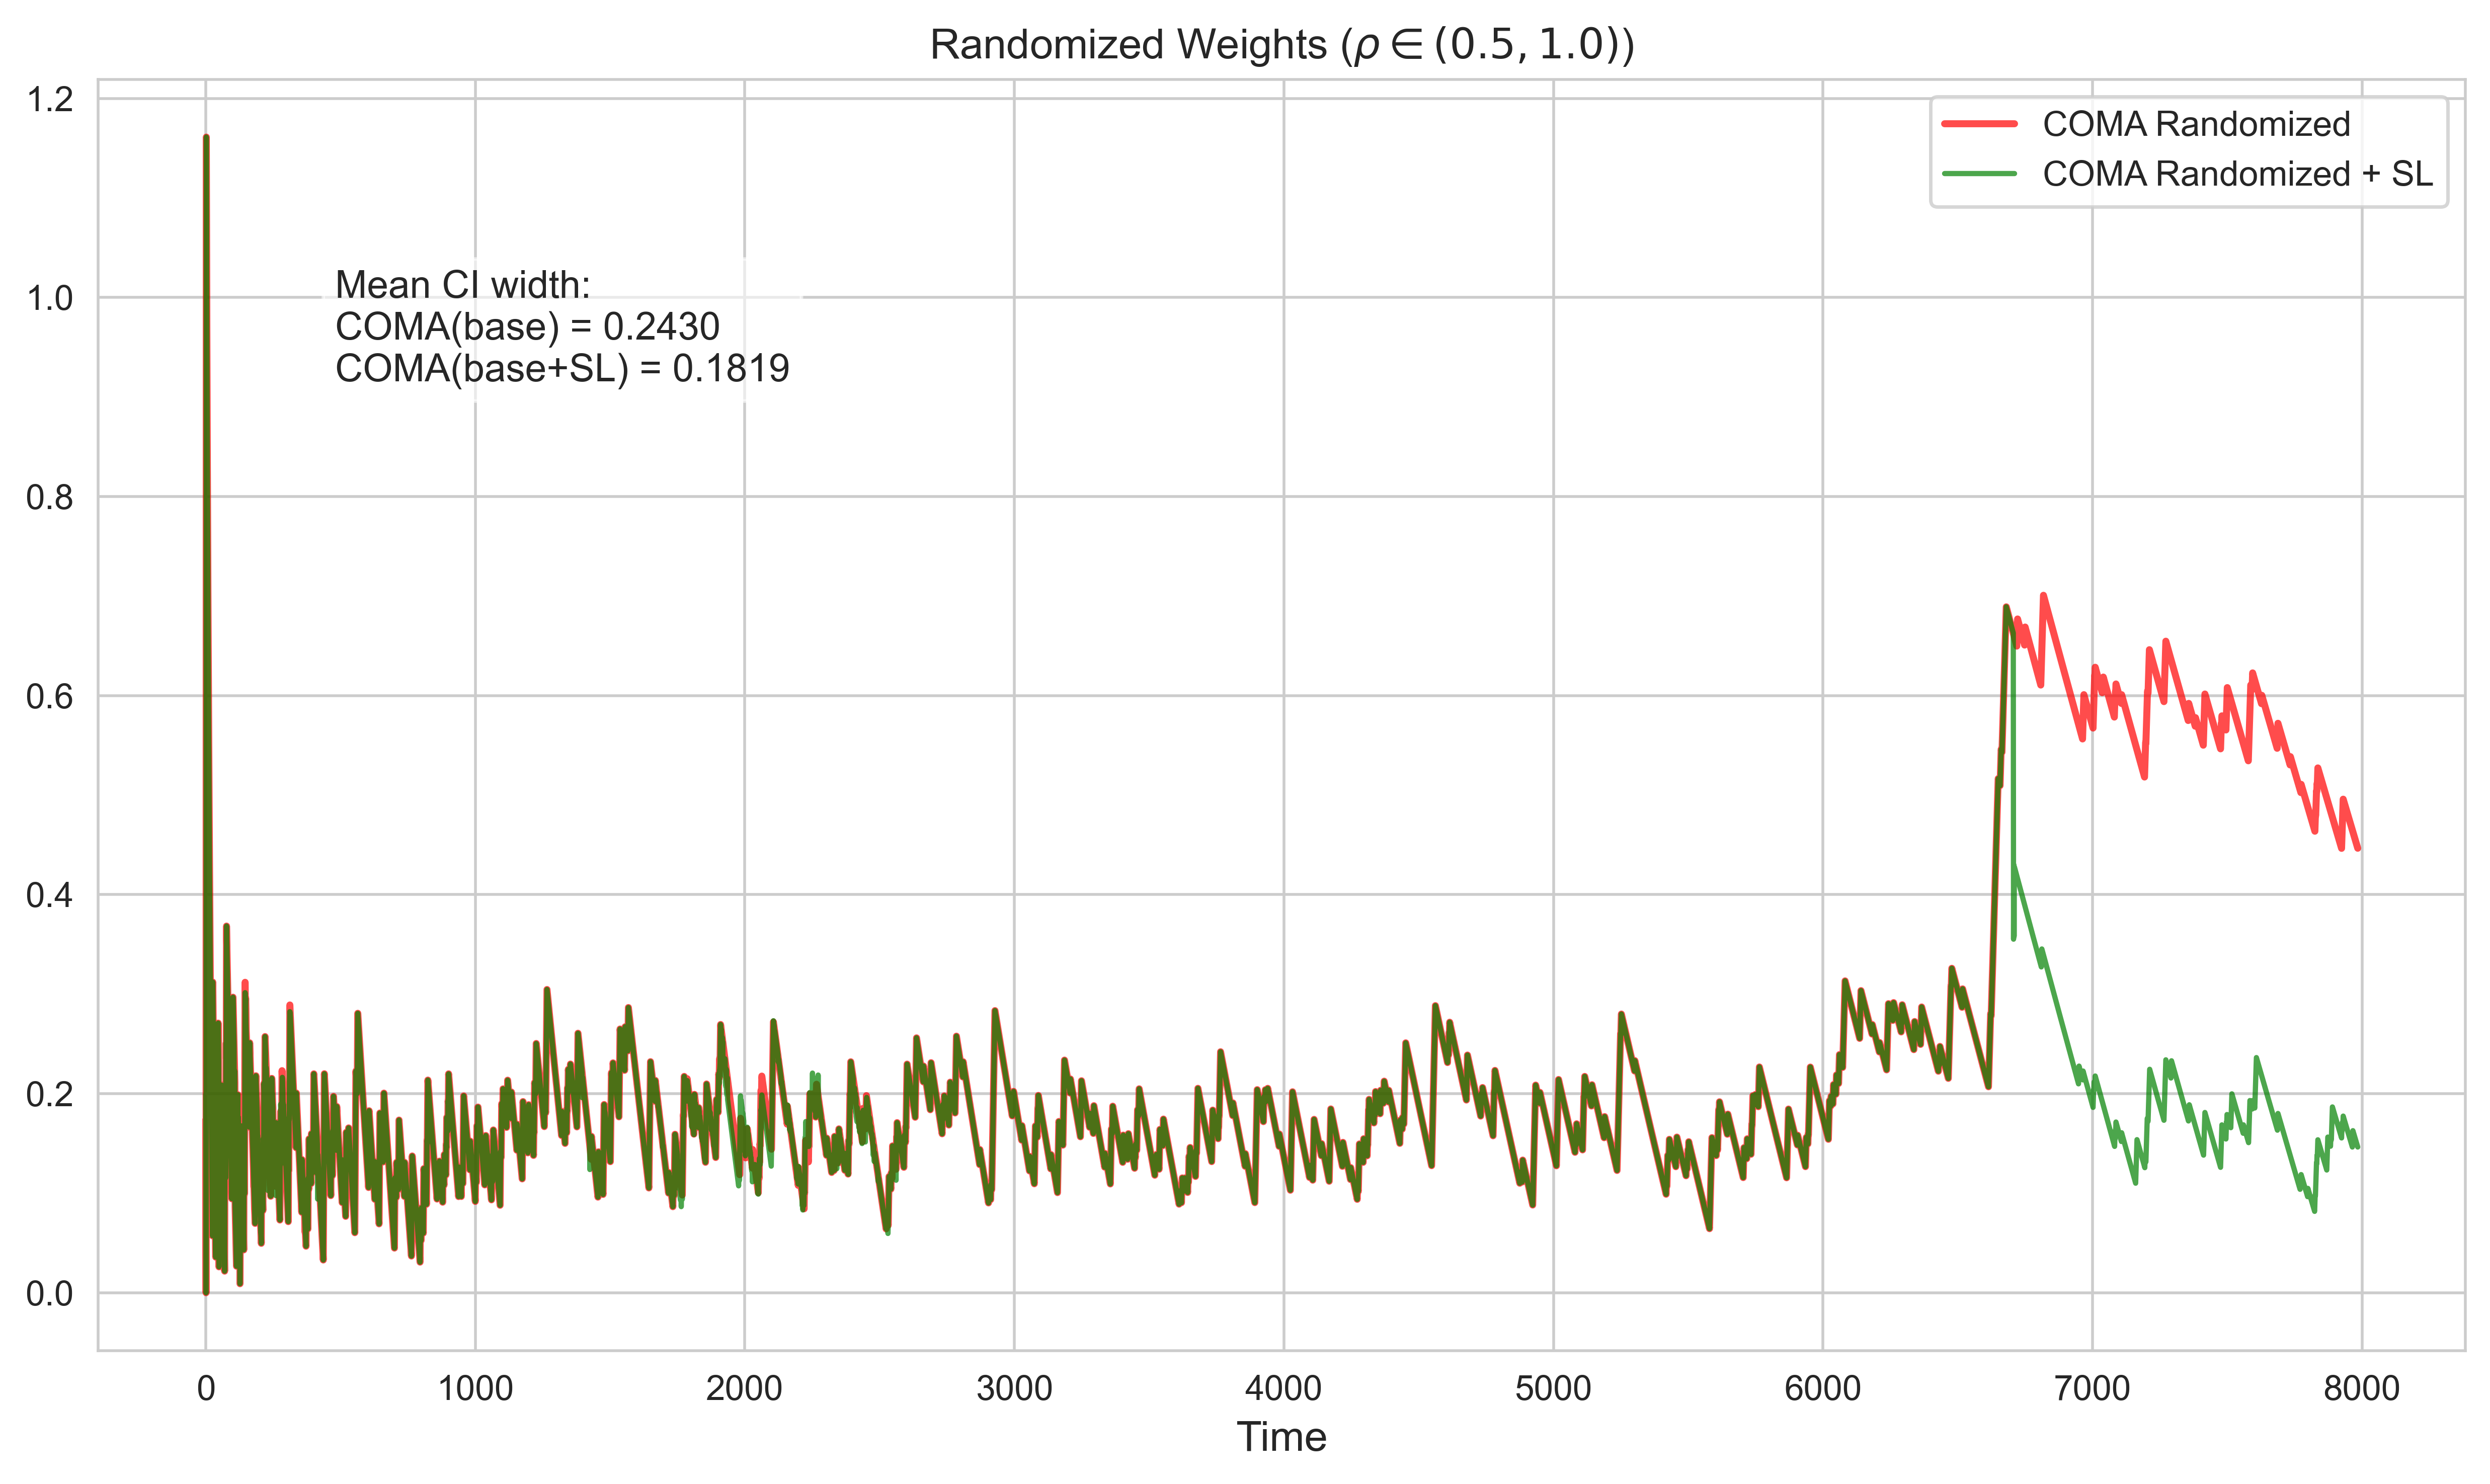

In [38]:

min_len = min(
    len(results_jd_lstm1['q_decaying']),
    len(results_jd_lstm2['q_decaying']),
    len(results_jd_lstm3['q_decaying']),
    len(results_super_lstm['q_decaying']),
    len(y_true_test)
)

ci_matrix_sl = np.column_stack([
    CI_lstm_decaying_model1[-min_len:],
    CI_lstm_decaying_model2[-min_len:],
    CI_lstm_decaying_model3[-min_len:],
    CI_sp_decaying[-min_len:]
])
adahedAlg_sl = adahedge(loss_matrix=ci_matrix_sl)

intervals_lstm1 = np.column_stack([
    y_pred_lstm1[-min_len:] - results_jd_lstm1['q_decaying'][-min_len:],
    y_pred_lstm1[-min_len:] + results_jd_lstm1['q_decaying'][-min_len:]
])

intervals_lstm2 = np.column_stack([
    y_pred_lstm2[-min_len:] - results_jd_lstm2['q_decaying'][-min_len:],
    y_pred_lstm2[-min_len:] + results_jd_lstm2['q_decaying'][-min_len:]
])

intervals_lstm3 = np.column_stack([
    y_pred_lstm3[-min_len:] - results_jd_lstm3['q_decaying'][-min_len:],
    y_pred_lstm3[-min_len:] + results_jd_lstm3['q_decaying'][-min_len:]
])



intervals_sp = np.column_stack([
    super_preds_lstm[-min_len:] - results_super_lstm['q_decaying'][-min_len:],
    super_preds_lstm[-min_len:] + results_super_lstm['q_decaying'][-min_len:]
])
intervals_list_sl = [intervals_lstm1, intervals_lstm2, intervals_lstm3, intervals_sp]
weights_sl = adahedAlg_sl["weights"]
y_test_aligned = y_true_test[-min_len:]
result_sl = coma_loop(intervals_list_sl, weights_sl, y_test_aligned)

print("Mean randomized coverage:", result_sl["mean_wm_cov"])

intervals_list_plain = [intervals_lstm1, intervals_lstm2, intervals_lstm3]
weights_plain = adahedAlg["weights"]
result_plain = coma_loop(intervals_list_plain, weights_plain, y_test_aligned)
pi_wm_plain  = result_plain["pi_wm"]
coma_width_rand = np.array([loss_fun(ci) for ci in pi_wm_plain])
pi_wm_sl  = result_sl["pi_wm"]

coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])

print("Mean CI width — COMA (rand) + SL:", np.nanmean(coma_width_rand_sl))



# Randomized subplot 
plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
plt.plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
plt.title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.legend()

mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
plt.text(0.1, 0.85,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

#plt.suptitle("Sim1 (LSTM, Adahedge): Confidence Interval Widths: COMA(base) vs COMA(base+Super Learner)", fontsize=14)
plt.tight_layout()
plt.savefig("lstm1_adahedge_line_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

#### boxplot

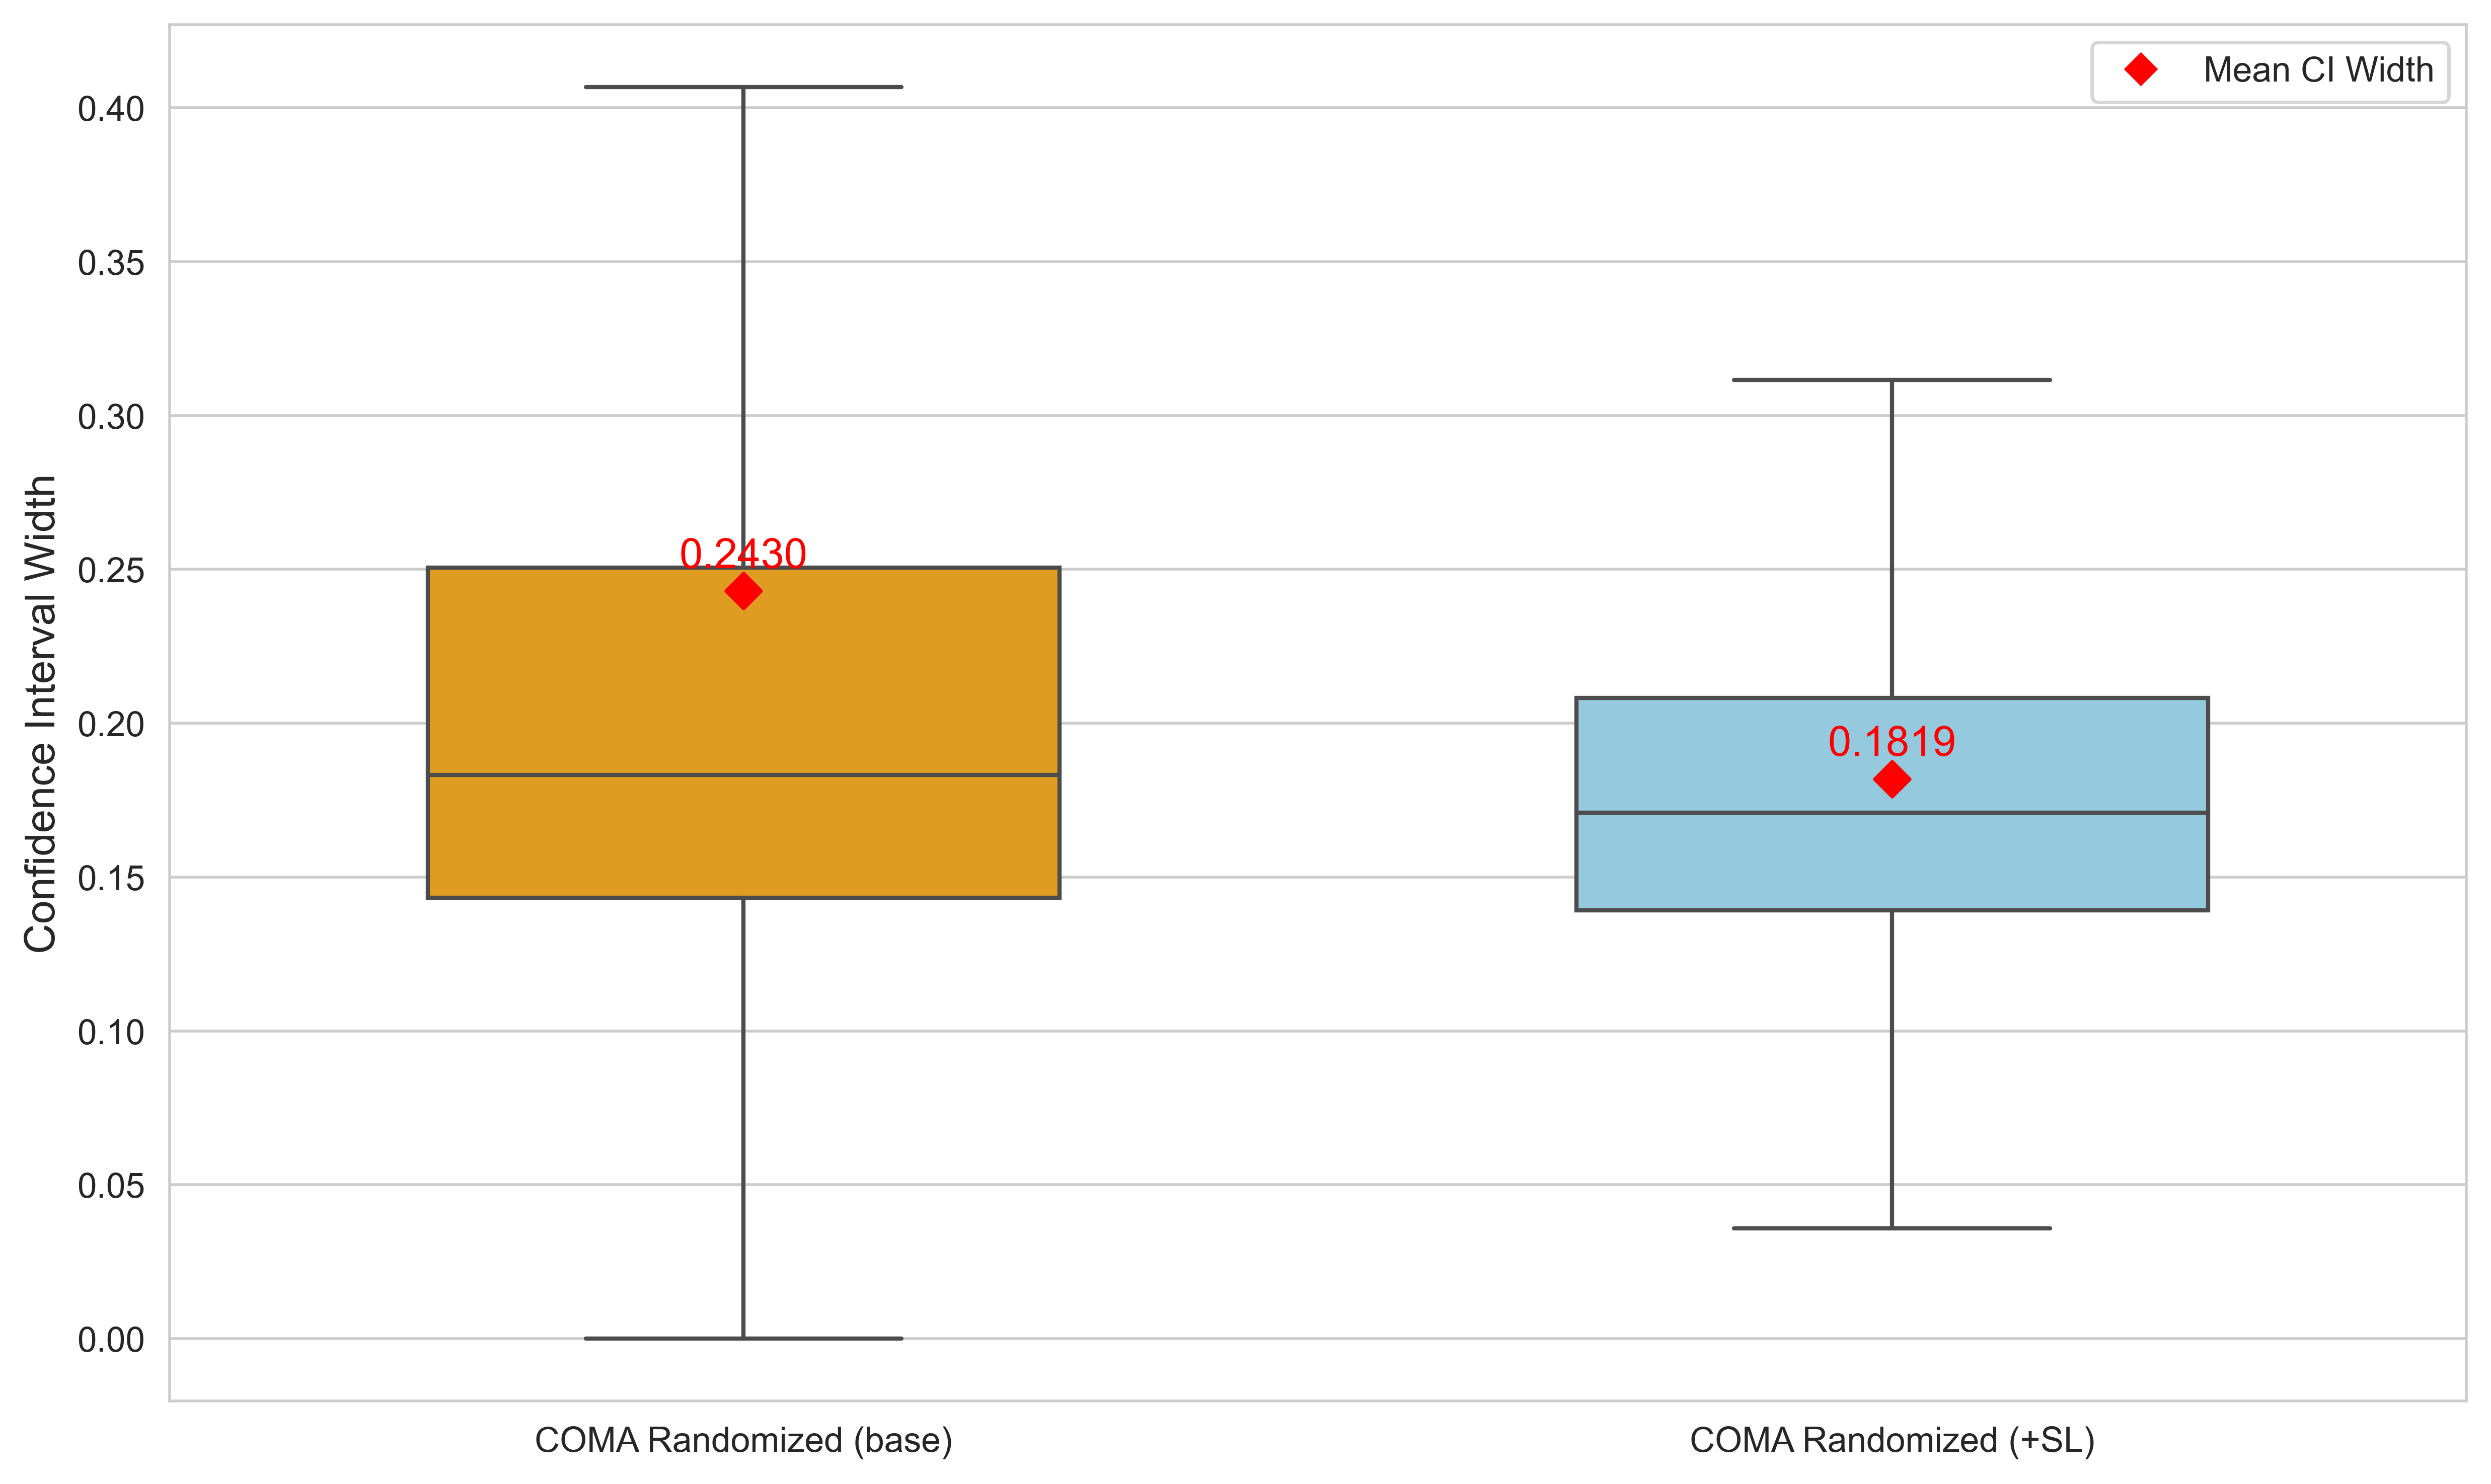

In [39]:
data_dict = {
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

palette = {"COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

plt.figure(figsize=(10, 6), dpi=500)

# Boxplot (randomized methods only)
sns.boxplot(
    x="Method",
    y="CI Width",
    data=df_long[df_long["Method"].isin(rand_methods)],
    order=rand_methods,
    palette=palette,
    showfliers=False,
    width=0.55,
    linewidth=1.2
)

# Mean CI width (red diamonds)
means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    plt.scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    plt.text(
        i,
        means_rand[i] + 0.005,
        f"{means_rand[i]:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        color="red"
    )

plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.legend(
    handles=[plt.Line2D([0], [0], color="red", marker="D",
                        linestyle="", label="Mean CI Width")],
    loc="upper right"
)

#plt.suptitle("Sim1 (LSTM, Adahedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("lstm1_adahedge_boxplot_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

#### smooth

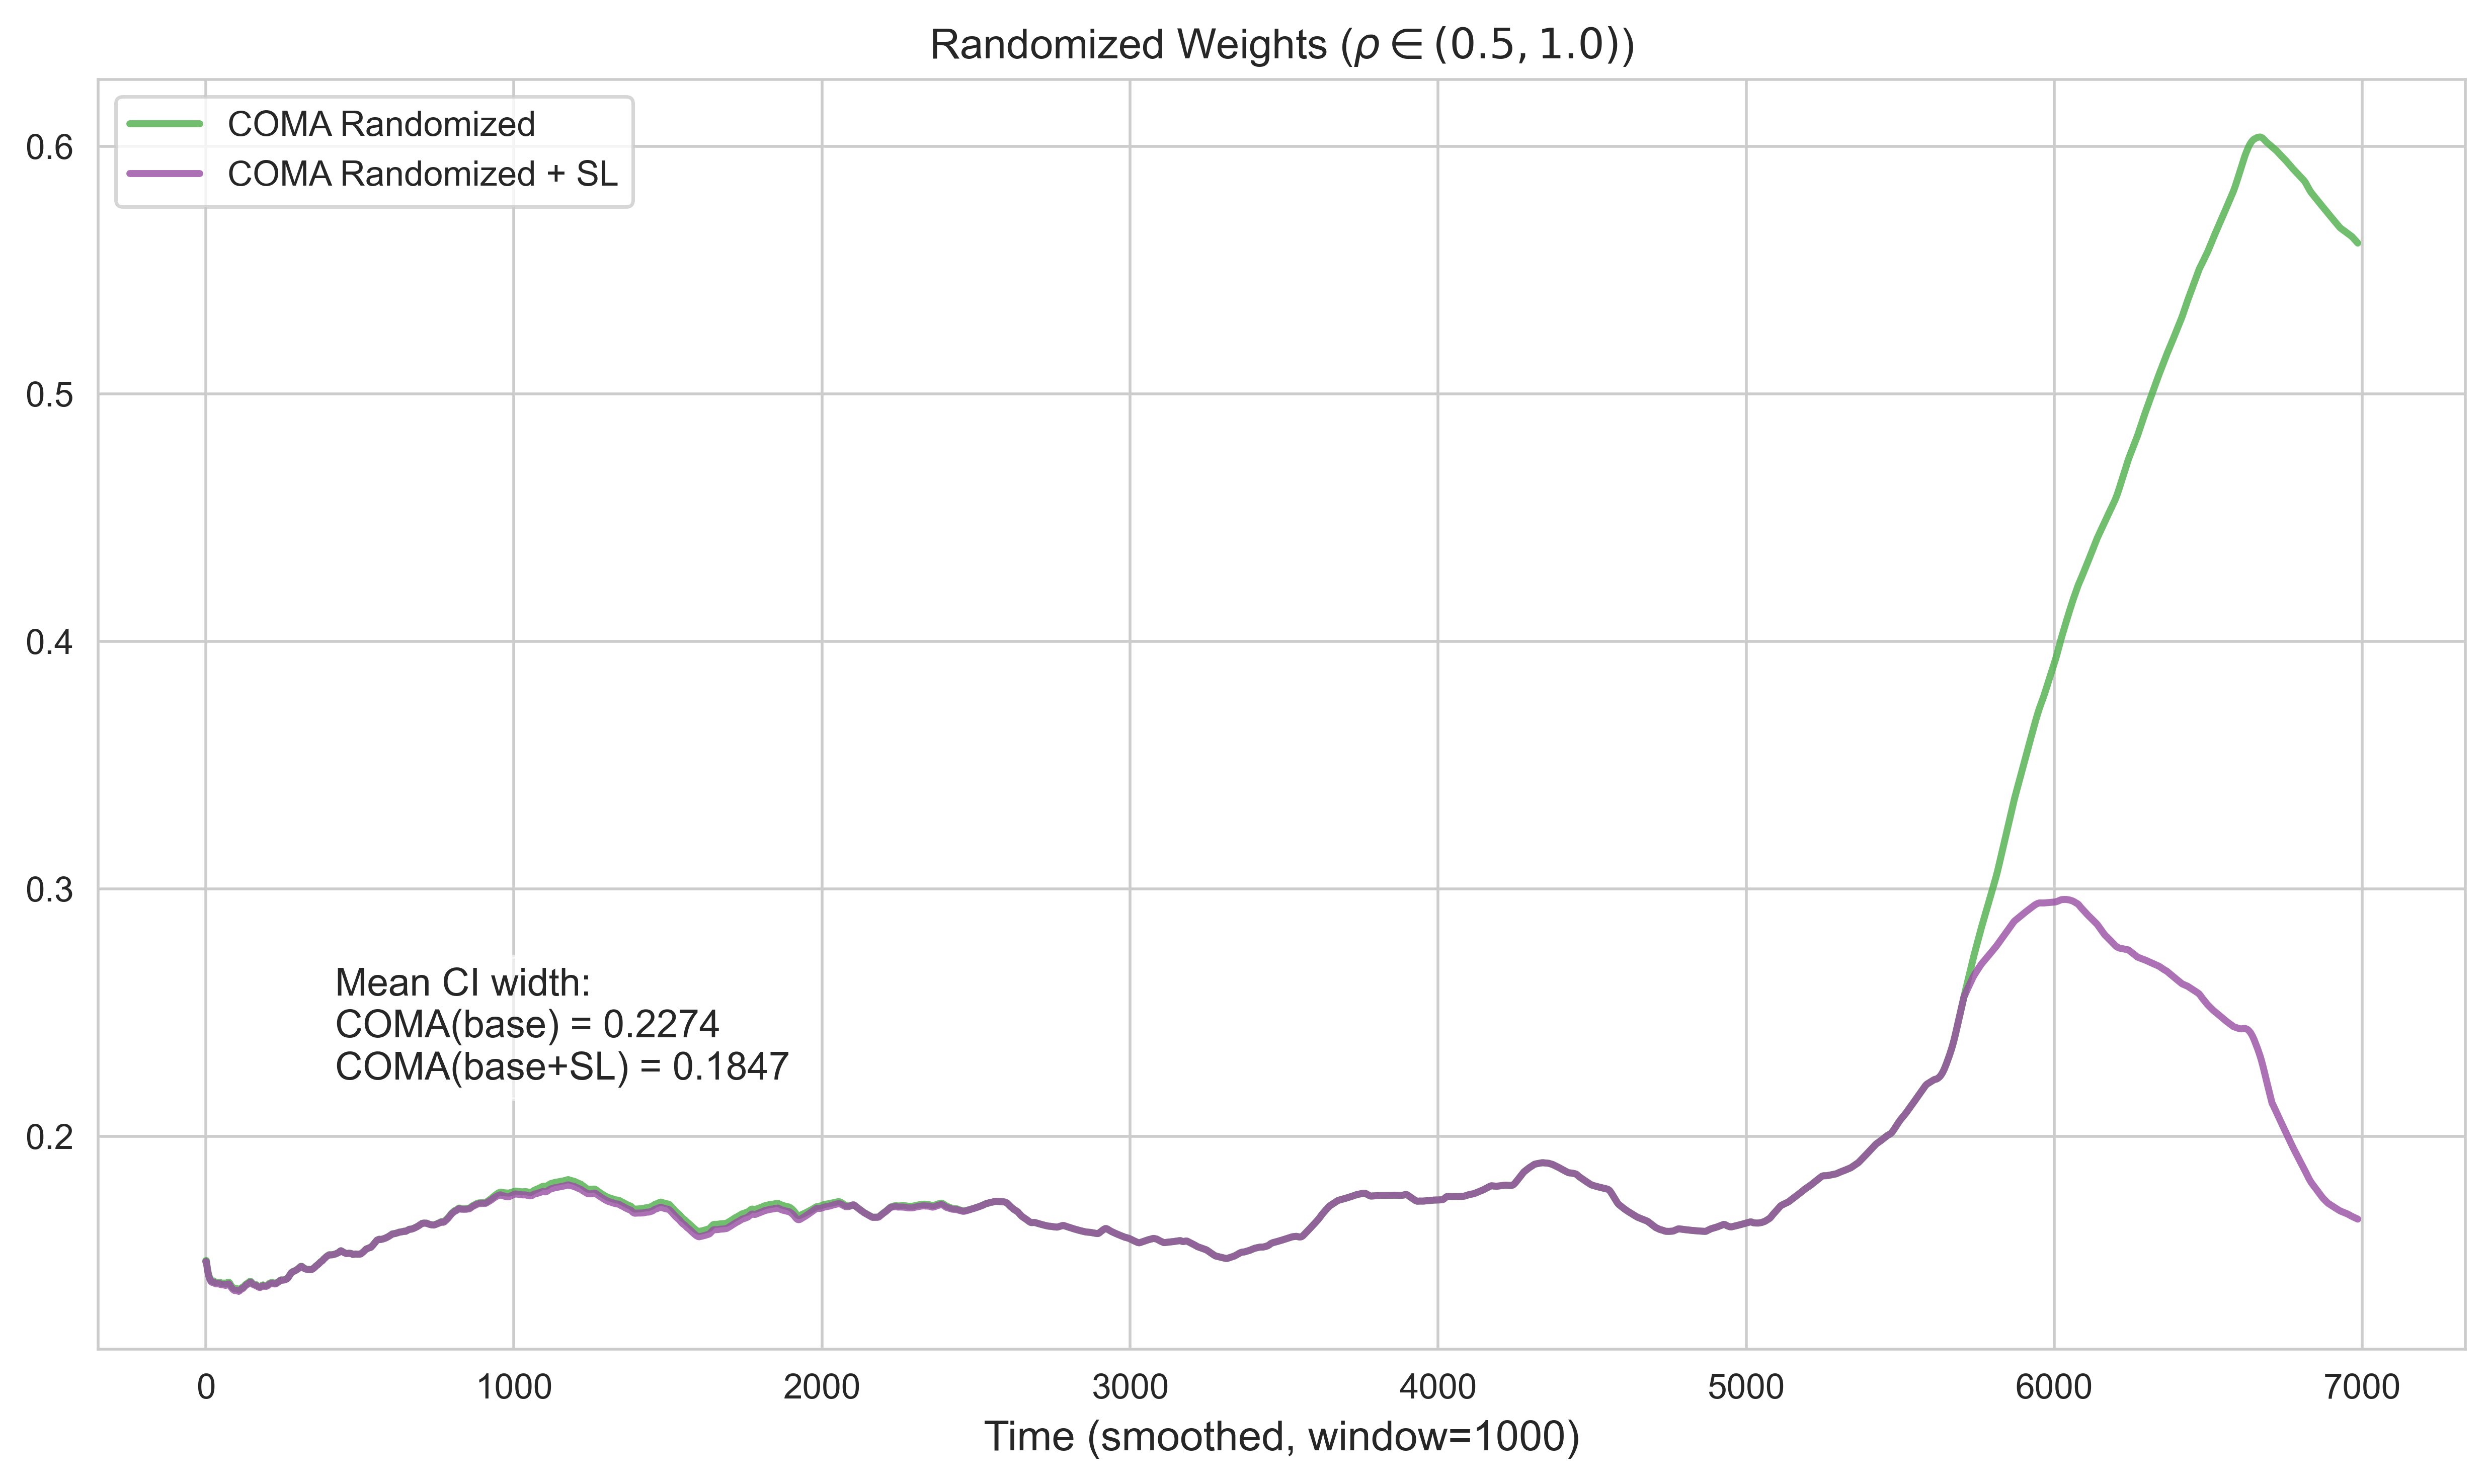

In [41]:

#coma_width_det_smooth     = smooth_series(coma_width_det, window=1000)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
#coma_width_det_sl_smooth  = smooth_series(coma_width_det_sl, window=1000)
coma_width_rand_sl_smooth = smooth_series(coma_width_rand_sl, window=1000)

# Randomized subplot 
plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
plt.plot(coma_width_rand_sl_smooth, label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
plt.title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
plt.xlabel("Time (smoothed, window=1000)", fontsize=12)
plt.legend()
mean_rand = np.nanmean(coma_width_rand_smooth)
mean_rand_sl = np.nanmean(coma_width_rand_sl_smooth)
plt.text(0.1, 0.3,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

#plt.suptitle("Sim1 (LSTM, Adahedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("lstm1_adahedge_smooth_line_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

## Hedge 

### coma v.s sl 

Mean randomized coverage (COMA base): 0.8869129618033813
Mean randomized coverage (COMA+SL): 0.8847839699436444
Mean CI width — COMA(base, rand): 0.23919063403378515
Mean CI width — COMA(base+SL, rand): 0.17519557476274064


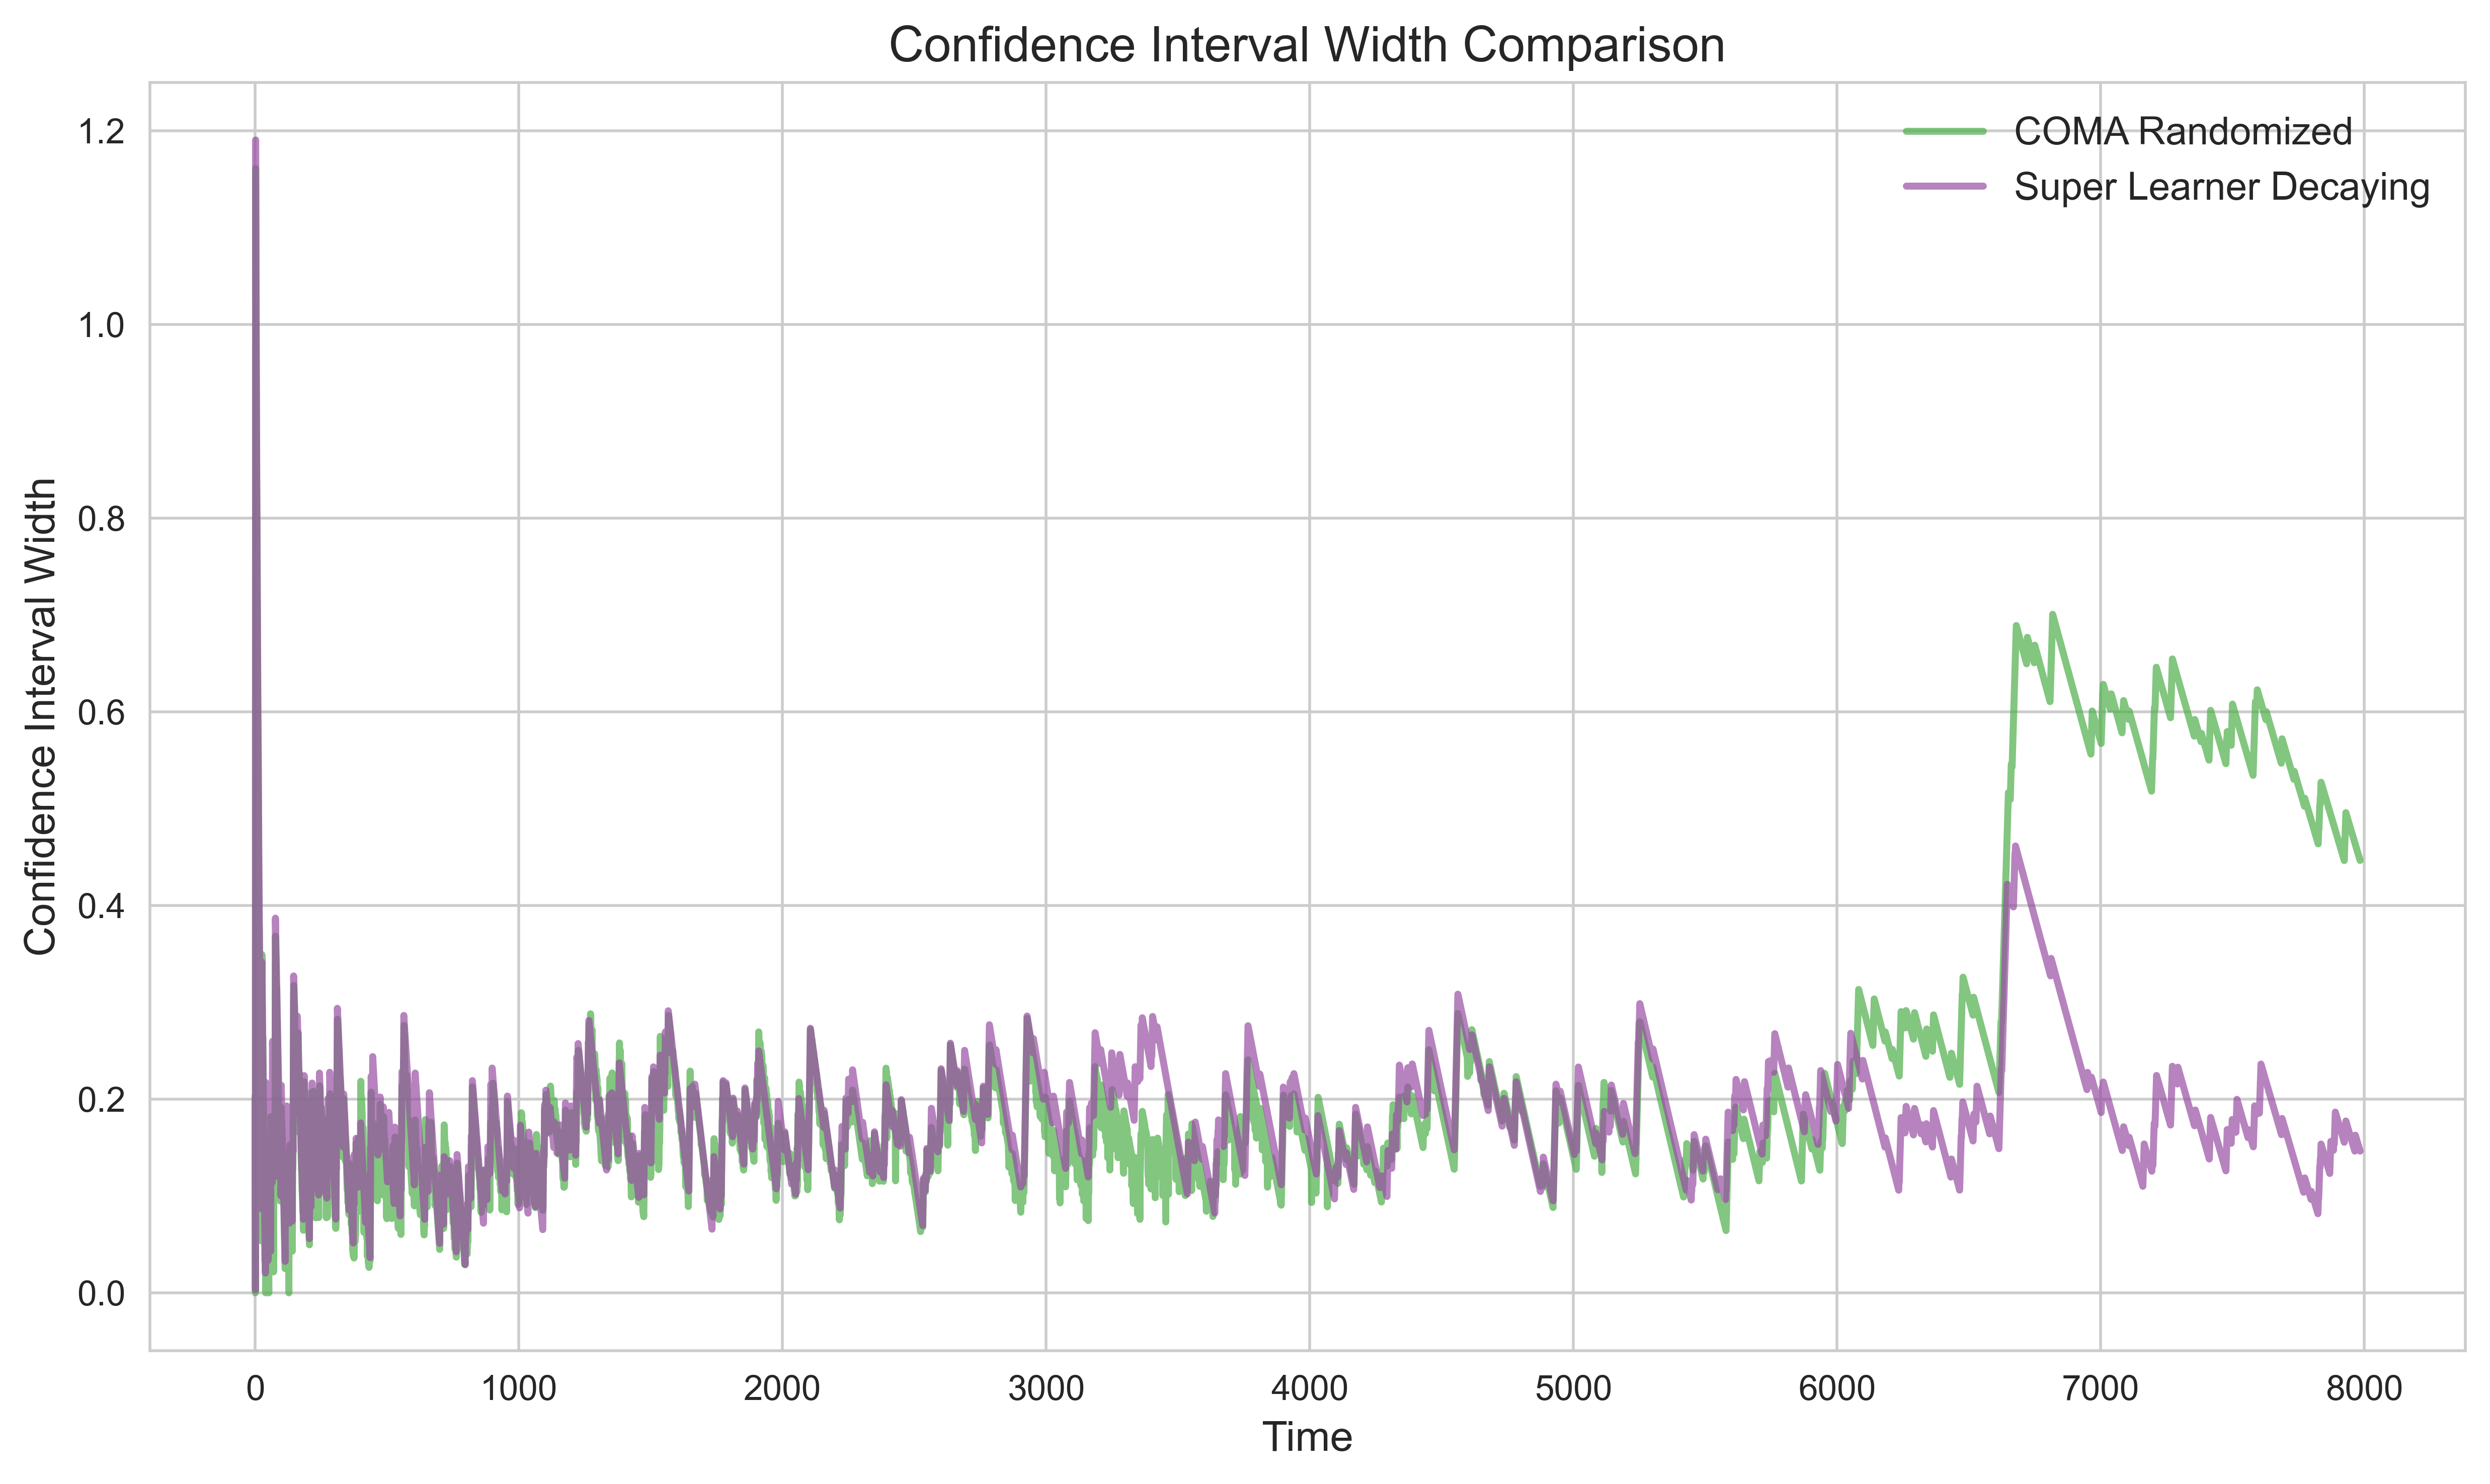

Mean CI width — COMA(base, rand): 0.2239977759449251
Mean CI width — SL: 0.1846952724507194


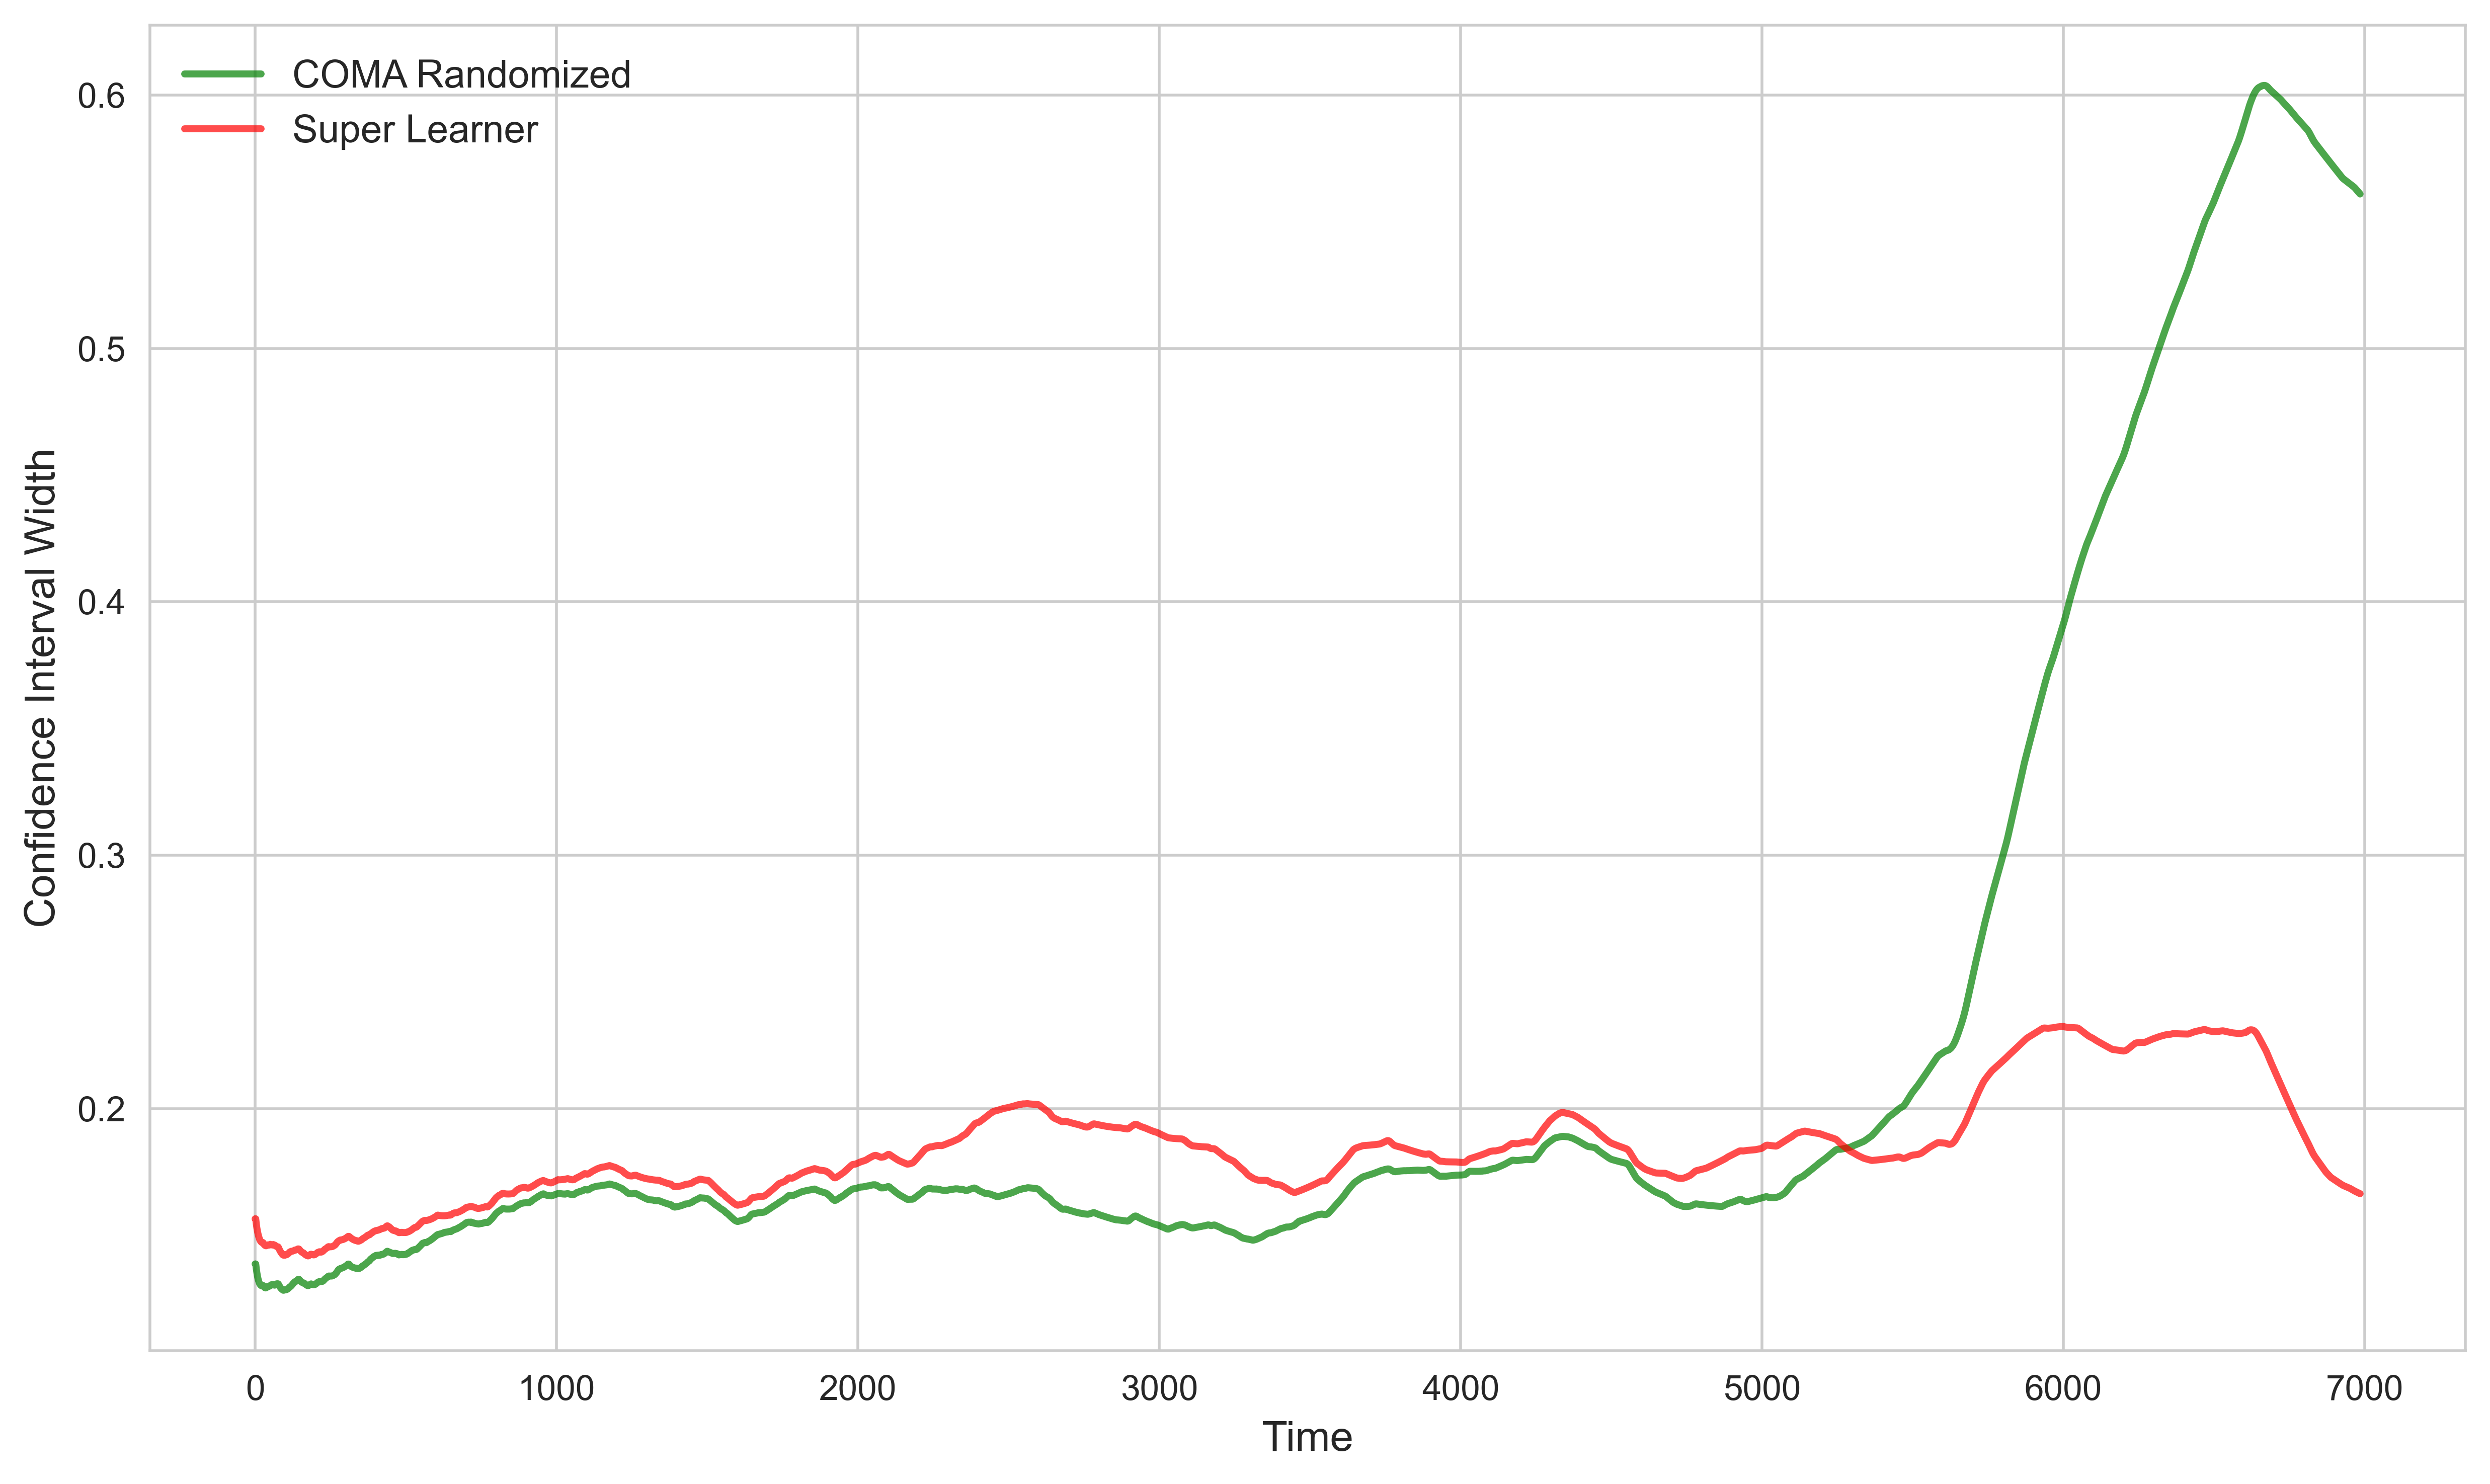

In [50]:

hedAlg_base = hedge(ci_matrix, eta=0.1)        # shape (N,3)
hedAlg_sl   = hedge(ci_matrix_sl, eta=0.1)     # shape (N,4)

weights_base = hedAlg_base["weights"]
weights_sl   = hedAlg_sl["weights"]

N_base, K_base = weights_base.shape
N_sl, K_sl     = weights_sl.shape


min_len = min(len(y_true_test), N_base, N_sl)
y_test_aligned = y_true_test[-min_len:]

pi_wm_base = []
pi_wm_sl = []

wm_cov_base = np.full(min_len, np.nan)
wm_cov_sl  = np.full(min_len, np.nan)

for i in range(min_len):
    rho_rand = np.random.uniform(0.5,1.0)

    # Base (3 experts) 
    conf_base = np.vstack([intervals_list_plain[j][i] for j in range(3)])
    wmaj_int_base = majority_vote(conf_base, w=weights_base[i], rho=rho_rand)
    pi_wm_base.append(wmaj_int_base)
    wm_cov_base[i] = covr_fun(wmaj_int_base, y_test_aligned[i])

    # Base+SL (4 experts) 
    conf_sl = np.vstack([intervals_list_sl[j][i] for j in range(4)])
    wmaj_int_sl = majority_vote(conf_sl, w=weights_sl[i], rho=rho_rand)  # same rho_rand

    pi_wm_sl.append(wmaj_int_sl)
    wm_cov_sl[i] = covr_fun(wmaj_int_sl, y_test_aligned[i])

coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])


print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))

# plot (coma v.s sl)
plt.figure(figsize=(10, 6), dpi=500)

plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color=colors[2])
plt.plot(CI_sp_decaying, label='Super Learner Decaying', linewidth=2, alpha=0.7, color=colors[3])

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
plt.title('Confidence Interval Width Comparison', fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# plot (coma v.s. sl smoother)
coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
sl_smooth = smooth_series(CI_super_decaying, window=1000)   

print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand_smooth))
print("Mean CI width — SL:", np.nanmean(sl_smooth))

plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA Randomized', linewidth=2, alpha = 0.7, color='green')
plt.plot(sl_smooth, label='Super Learner', linewidth=2, alpha = 0.7, color='red')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Confidence Interval Width', fontsize=12)
#plt.title("Sim1 (LSTM, Adahedge, Smoothed): CI Widths — COMA(base) vs Super Learner", fontsize=14)

plt.legend(frameon=False, fontsize=11, loc='upper left')
plt.tight_layout()
plt.savefig("lstm1_hedge_smooth_line_base.png", dpi=500, bbox_inches="tight")
plt.show()

### coma v.s. coma+sl

Mean randomized coverage (COMA base): 0.8869129618033813
Mean randomized coverage (COMA+SL): 0.8847839699436444
Mean CI width — COMA(base, rand): 0.23919063403378515
Mean CI width — COMA(base+SL, rand): 0.17519557476274064


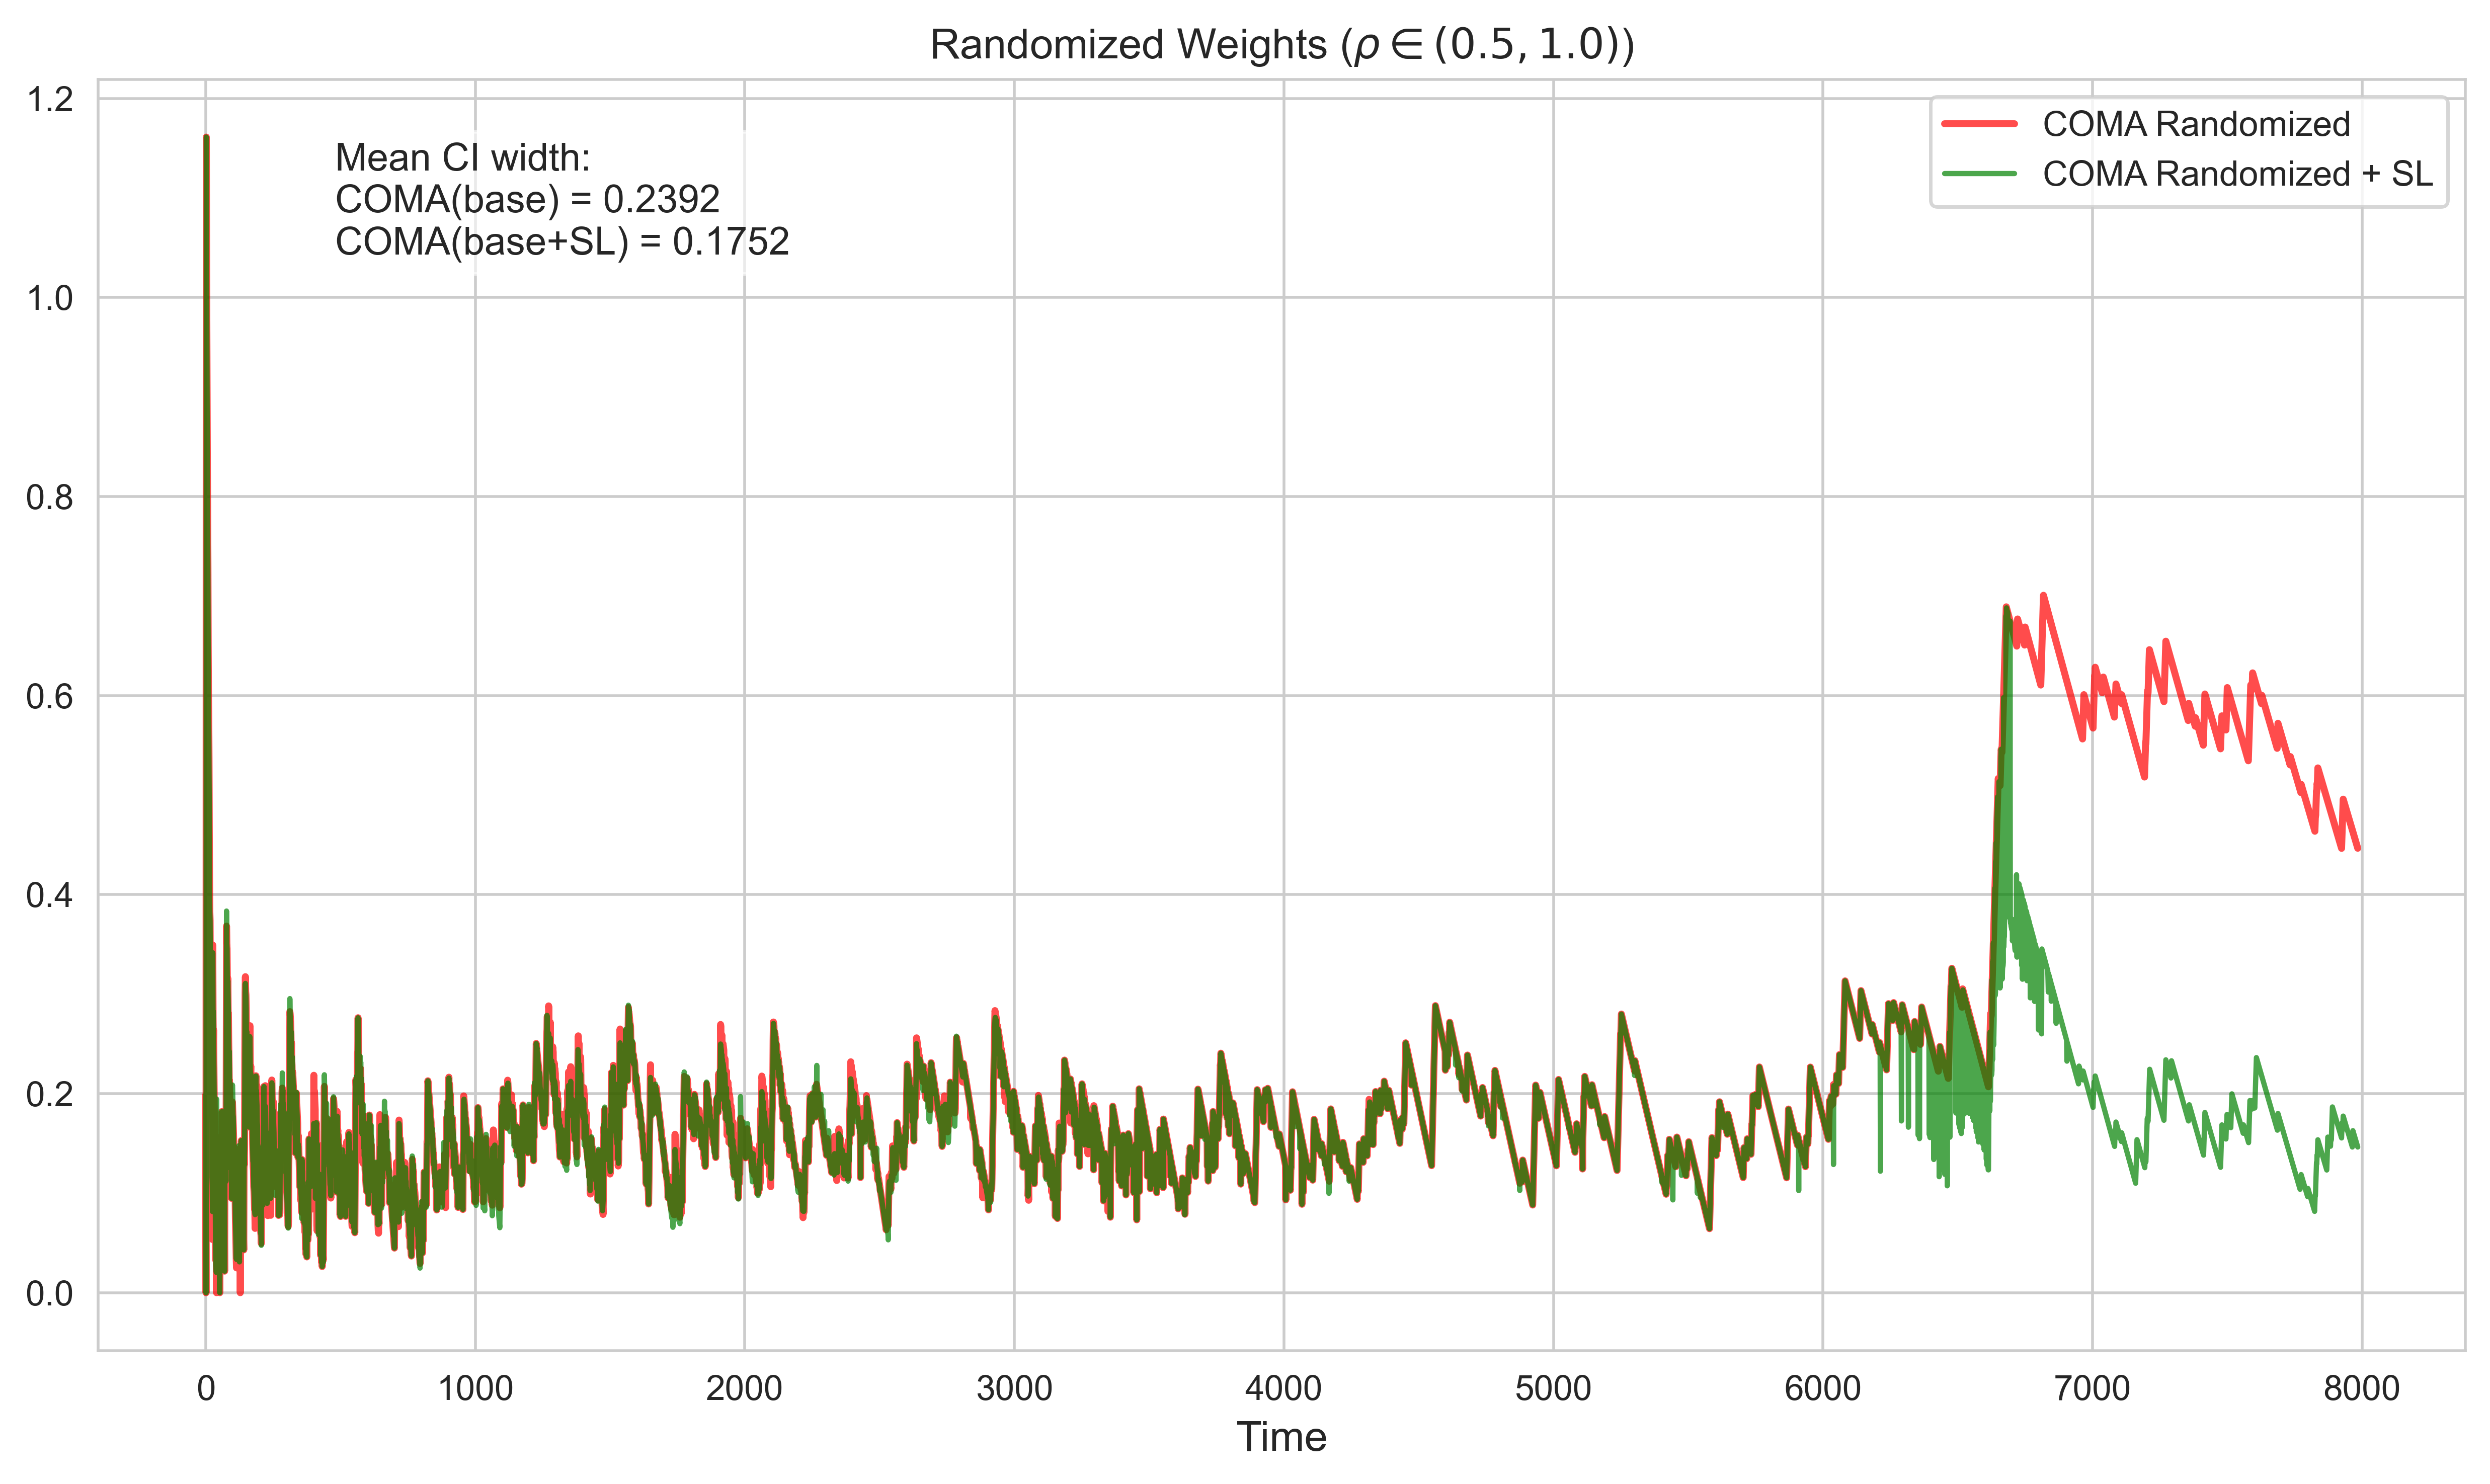

In [51]:

coma_width_rand    = np.array([loss_fun(ci) for ci in pi_wm_base])
coma_width_rand_sl = np.array([loss_fun(ci) for ci in pi_wm_sl])


print("Mean randomized coverage (COMA base):", np.nanmean(wm_cov_base))
print("Mean randomized coverage (COMA+SL):", np.nanmean(wm_cov_sl))

print("Mean CI width — COMA(base, rand):", np.nanmean(coma_width_rand))
print("Mean CI width — COMA(base+SL, rand):", np.nanmean(coma_width_rand_sl))


#  Randomized subplot
plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand, label='COMA Randomized', linewidth=2, alpha=0.7, color='red')
plt.plot(coma_width_rand_sl, label='COMA Randomized + SL', linewidth=1.5, alpha=0.7, color='green')
plt.title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
plt.xlabel("Time", fontsize=12)
plt.legend()

# Annotate means
mean_rand = np.nanmean(coma_width_rand)
mean_rand_sl = np.nanmean(coma_width_rand_sl)
plt.text(0.1, 0.95,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
             fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

#plt.suptitle("Sim1 (LSTM, Hedge): Confidence Interval Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("lstm1_hedge_line_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

#### boxplot

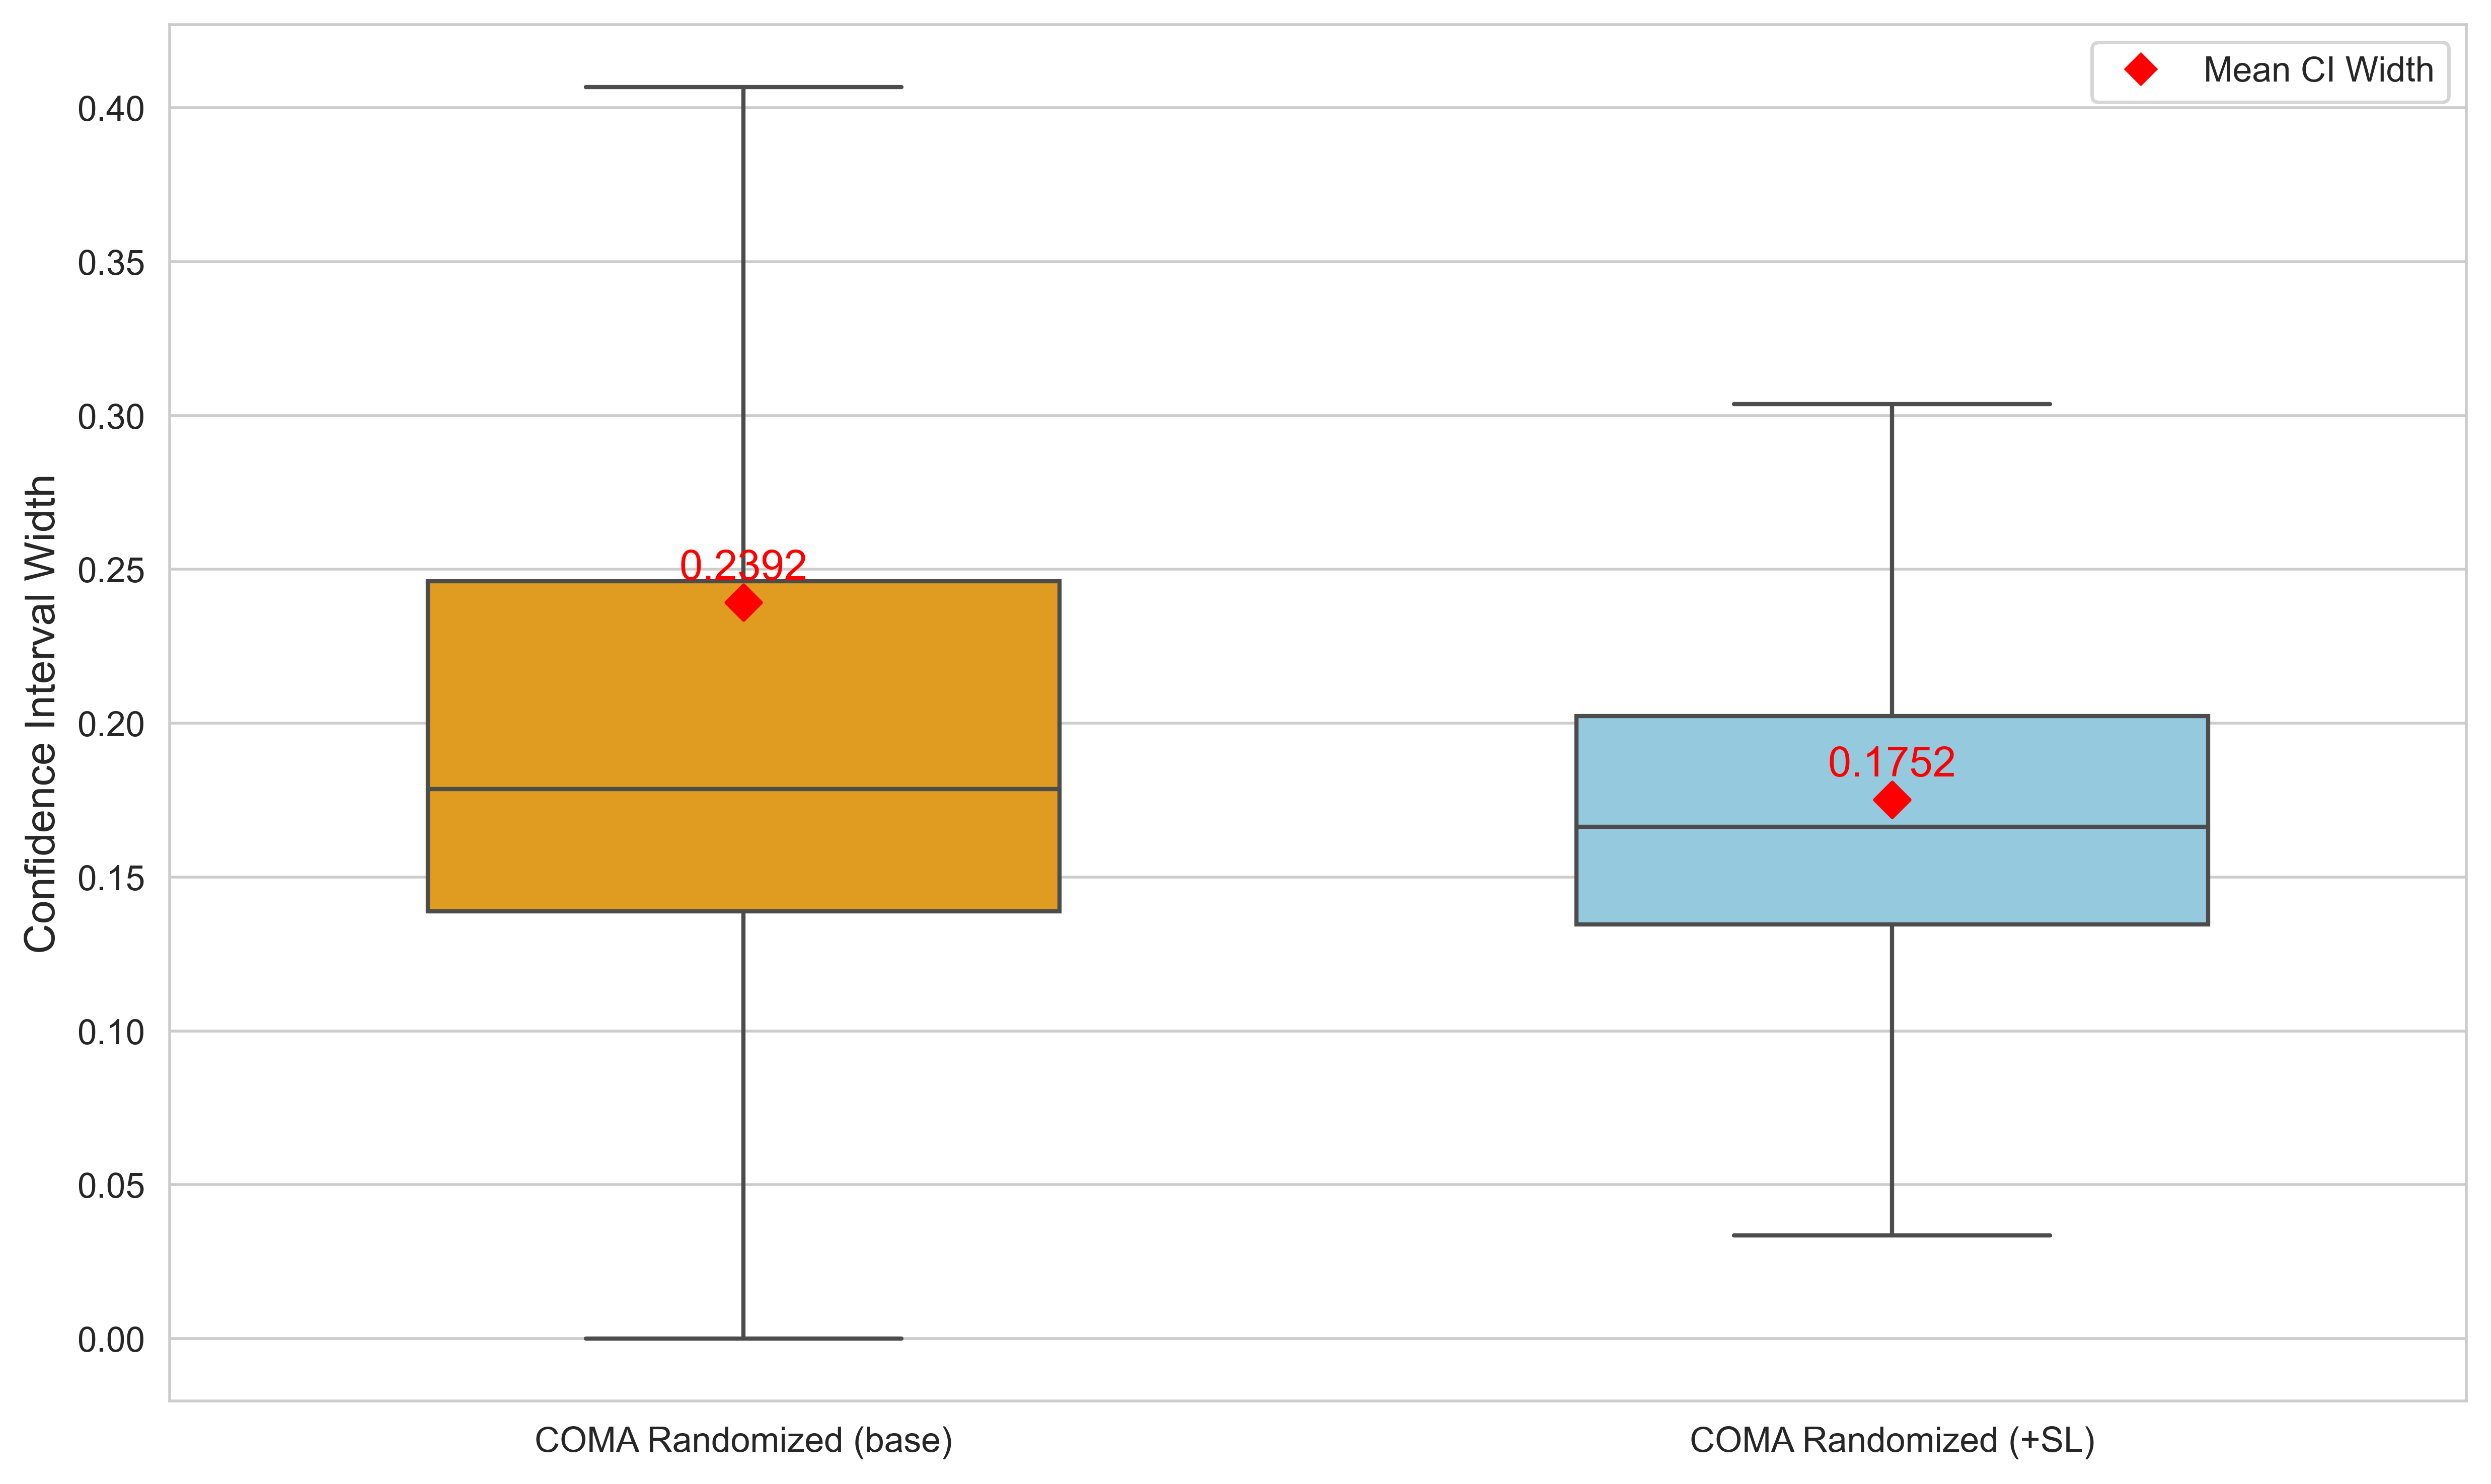

In [52]:
data_dict = {
    "COMA Randomized (base)": coma_width_rand,
    "COMA Randomized (+SL)": coma_width_rand_sl
}

df_box = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in data_dict.items()]))
df_long = df_box.melt(var_name="Method", value_name="CI Width")
rand_methods = ["COMA Randomized (base)", "COMA Randomized (+SL)"]

palette = {"COMA Randomized (base)": "orange",
           "COMA Randomized (+SL)": "skyblue"}

plt.figure(figsize=(10, 6), dpi=500)

# Boxplot (randomized methods only)
sns.boxplot(
    x="Method",
    y="CI Width",
    data=df_long[df_long["Method"].isin(rand_methods)],
    order=rand_methods,
    palette=palette,
    showfliers=False,
    width=0.55,
    linewidth=1.2
)

# Mean CI width (red diamonds)
means_rand = [np.nanmean(data_dict[m]) for m in rand_methods]
for i, m in enumerate(rand_methods):
    plt.scatter(i, means_rand[i], color="red", marker="D", s=50, zorder=3)
    plt.text(
        i,
        means_rand[i] + 0.005,
        f"{means_rand[i]:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        color="red"
    )

plt.xlabel("")
plt.ylabel("Confidence Interval Width", fontsize=12)
plt.legend(
    handles=[plt.Line2D([0], [0], color="red", marker="D",
                        linestyle="", label="Mean CI Width")],
    loc="upper right"
)

#plt.suptitle("Sim1 (LSTM, Hedge): Boxplot of CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("lstm1_hedge_boxplot_comasl.png", dpi=500, bbox_inches="tight")
plt.show()

#### smooth 

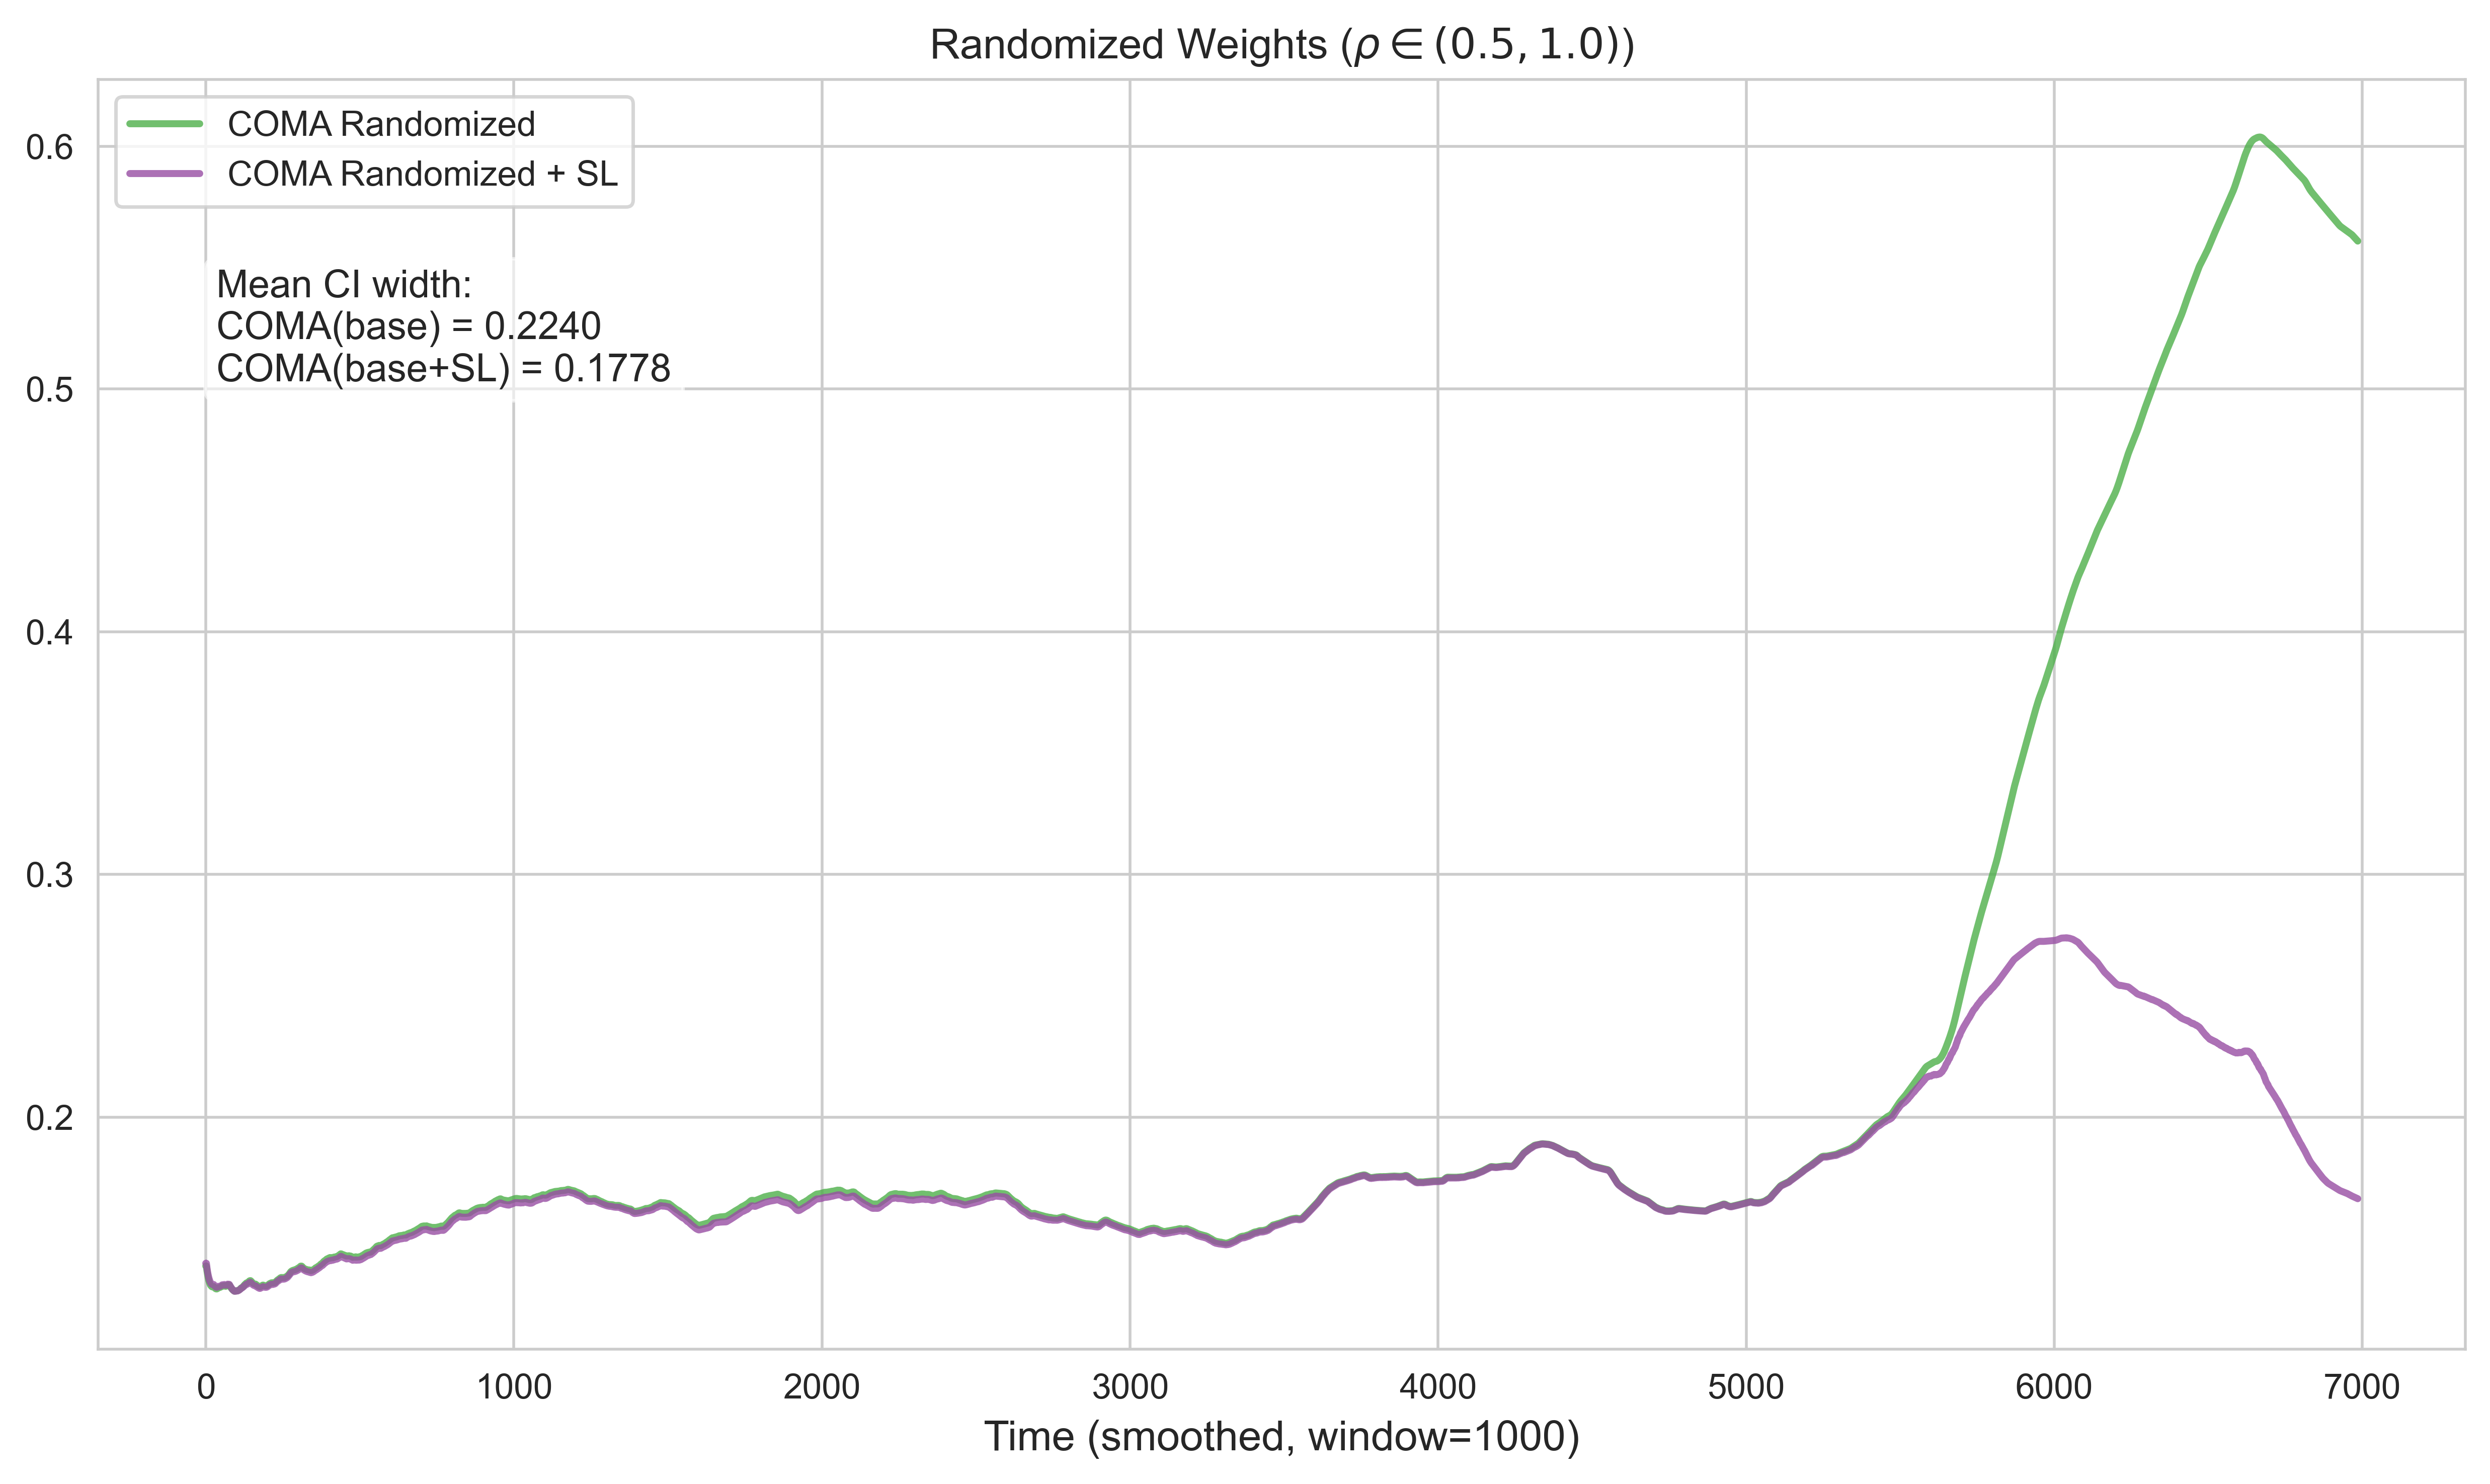

In [56]:

coma_width_rand_smooth    = smooth_series(coma_width_rand, window=1000)
coma_width_rand_sl_smooth = smooth_series(coma_width_rand_sl, window=1000)

# Randomized subplot 
plt.figure(figsize=(10, 6), dpi=500)
plt.plot(coma_width_rand_smooth, label='COMA Randomized', linewidth=2, alpha=0.8, color=colors[2])
plt.plot(coma_width_rand_sl_smooth, label='COMA Randomized + SL', linewidth=2, alpha=0.8, color=colors[3])
plt.title("Randomized Weights ($\\rho \\in (0.5,1.0)$)", fontsize=12)
plt.xlabel("Time (smoothed, window=1000)", fontsize=12)
plt.legend()
mean_rand = np.nanmean(coma_width_rand_smooth)
mean_rand_sl = np.nanmean(coma_width_rand_sl_smooth)
plt.text(0.05, 0.85,
         f"Mean CI width:\nCOMA(base) = {mean_rand:.4f}\nCOMA(base+SL) = {mean_rand_sl:.4f}",
         transform=plt.gca().transAxes,
         fontsize=11, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

#plt.suptitle("Sim1 (LSTM, Hedge, Smoothed): CI Widths — COMA(base) vs COMA+Super Learner", fontsize=14)
plt.tight_layout()
plt.savefig("lstm1_hedge_smooth_line_comasl.png", dpi=500, bbox_inches="tight")
plt.show()